# LEGO VR — Merged Data Analysis Notebook

**Input:** one `<participant_id>_synced.csv` from `../data/merged/`  
**Output:** analysis tables and plots for one participant. No new preprocessing files are written.

### Pipeline overview
1. **Load** one already synchronized participant file from `data/merged`
2. **Validate schema** required analysis columns are present
3. **Filter analysis rows** remove missing `model_name` and training models `TM`
4. **Exclude invalid trials** remove unusable sessions.
5. **Summarize QC** using existing bad/interpolated flags from preprocessing
6. **Group gaze objects** collapse raw collider names into semantic `hit_obj_group` labels
7. **Classify gaze space** assign each sample to `model_area`, `resource_area`, `work_area`, or another broad area
8. **Annotate eye events** add consecutive `saccade_id`, `fixation_id`, `event_duration_ms`, and grouped `fixation_target`
9. **Plots** fixation/saccade durations, grabs, match rates, and angular velocity trace

### Important upstream assumptions
The following steps are already handled by earlier notebooks and are **not recomputed here**:
- eye/body sampling-rate checks
- eye/body interpolation
- gaze angular velocity
- MAD thresholding
- fixation/saccade sample classification
- eye/body synchronization




# 1. Imports & Configuration




In [80]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

try:
    import seaborn as sns
    sns.set_style("whitegrid")
except ImportError:
    plt.style.use("default")

DATA_DIR = Path("../data/merged")
PARTICIPANT_ID = "020"

FILE_PATH = DATA_DIR / f"{PARTICIPANT_ID}_synced.csv"

REQUIRED_COLUMNS = [
    "participant_id",
    "condition_number",
    "trial_number",
    "raw_timestamp",
    "time_ms",
    "event_type",
    "angular_velocity",
    "mad_threshold",
    "hit_obj_name",
    "object_position_z",
    "LeftHand_grabbed_name",
    "RightHand_grabbed_name",
]

GROUP_COLS = ["participant_id", "condition_number", "trial_number"]
LEFT_GRABBED_COL = "LeftHand_grabbed_name"
RIGHT_GRABBED_COL = "RightHand_grabbed_name"


# 2. Data Loading & Schema Check




In [81]:
def list_available_participants(data_dir=DATA_DIR):
    return sorted(path.stem.replace("_synced", "") for path in data_dir.glob("*_synced.csv"))


def load_synced_participant(participant_id=PARTICIPANT_ID, data_dir=DATA_DIR):
    participant_id = str(participant_id).zfill(3)
    file_path = data_dir / f"{participant_id}_synced.csv"
    if not file_path.exists():
        available = ", ".join(list_available_participants(data_dir))
        raise FileNotFoundError(
            f"Missing synced file: {file_path}\n"
            f"Available participants: {available}"
        )

    df = pd.read_csv(file_path, low_memory=False)
    if "participant_id" in df.columns:
        df["participant_id"] = df["participant_id"].astype(str).str.zfill(3)
    return df, file_path


def validate_required_columns(df, required_columns=REQUIRED_COLUMNS):
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise KeyError("Missing required column(s): " + ", ".join(missing))
    return True


df_raw, file_path = load_synced_participant(PARTICIPANT_ID)
validate_required_columns(df_raw)

print(f"Loaded: {file_path}")
print(f"Shape : {df_raw.shape[0]:,} rows x {df_raw.shape[1]:,} columns")
print(f"Participant IDs: {sorted(df_raw['participant_id'].dropna().astype(str).unique())}")
print(f"Conditions     : {sorted(df_raw['condition_number'].dropna().unique())}")
print(f"Trials         : {sorted(df_raw['trial_number'].dropna().unique())[:20]}")

df_raw.head(3)


Loaded: ../data/merged/020_synced.csv
Shape : 595,110 rows x 141 columns
Participant IDs: ['020']
Conditions     : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Trials         : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,bad_sample_RightFoot,is_interpolated_RightFoot,bad_sample_LeftFoot,is_interpolated_LeftFoot,bad_sample_Waist,is_interpolated_Waist,bad_sample_LeftHand,is_interpolated_LeftHand,bad_sample_RightHand,is_interpolated_RightHand
0,1000012645355749100,1779189548996,140.0037,2.000000,344867,0.0,Valid,0.193737,-0.431325,0.881150,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1000012645360748300,1779189548998,140.0037,0.318640,344868,0.0,Valid,0.154651,-0.395239,0.905466,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1000012645365747500,1779189548998,140.0037,0.336155,344869,0.0,Valid,0.127185,-0.379639,0.916351,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 3. Analysis Cleaning




In [82]:
def cleaning_function(df: pd.DataFrame) -> pd.DataFrame:
    """
    Filter rows for analysis only.

    Removes rows where model_name is missing or marks a training model (contains "TM").
    This does not redo any preprocessing from earlier notebooks.
    """
    out = df.copy()
    model = out["model_name"].astype("string")
    keep = model.notna() & ~model.str.contains("TM", case=False, na=False)
    return out.loc[keep].copy()


n_before = len(df_raw)
df = cleaning_function(df_raw)
n_after = len(df)
removed = n_before - n_after
removed_pct = 100 * removed / n_before if n_before else 0

print(f"Rows before cleaning: {n_before:,}")
print(f"Rows after cleaning : {n_after:,}")
print(f"Rows removed        : {removed:,} ({removed_pct:.2f}%)")

df.head(3)


Rows before cleaning: 595,110
Rows after cleaning : 319,626
Rows removed        : 275,484 (46.29%)


,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,bad_sample_RightFoot,is_interpolated_RightFoot,bad_sample_LeftFoot,is_interpolated_LeftFoot,bad_sample_Waist,is_interpolated_Waist,bad_sample_LeftHand,is_interpolated_LeftHand,bad_sample_RightHand,is_interpolated_RightHand
109511,1000013367234267600,1779190270437,859.9977,0.707672,489187,1.0,Valid,0.020012,0.159707,0.986962,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
109512,1000013367239268700,1779190270437,859.9977,0.708313,489188,1.0,Valid,0.020021,0.159712,0.986961,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
109513,1000013367244269800,1779190270437,859.9977,0.708878,489189,1.0,Valid,0.020024,0.159727,0.986958,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 4. Exclude invalid trials




In [83]:
def exclude_participant_models(df, participant_id, model_name):
    """
    Remove model(s) belonging to one participant.

    model_name:
        str          -> remove one model
        list[str]    -> remove multiple models
        None         -> remove the entire participant
    """
    participant_values = pd.to_numeric(
        df["participant_id"], errors="coerce"
    )
    target_participant = pd.to_numeric(
        pd.Series([participant_id]), errors="coerce"
    ).iloc[0]

    participant_mask = participant_values.eq(target_participant)

    if model_name is None:
        remove_mask = participant_mask
    else:
        models = [model_name] if isinstance(model_name, str) else model_name
        models = [str(model).strip().casefold() for model in models]

        model_mask = (
            df["model_name"]
            .astype("string")
            .str.strip()
            .str.casefold()
            .isin(models)
        )

        remove_mask = participant_mask & model_mask

    return df.loc[~remove_mask].copy()


# None means that the participant's entire session is excluded.
EXCLUSIONS = [
    ("013", "C3M4A"),
    ("016", ["C1M2A", "C2M1F"]),
    ("018", "C2M6A"),
    ("019", "C3M1F"),
    ("025", "C3M2A"),
    ("033", ["C3M1F", "C3M2A"]),
    ("035", "C3M6A"),
    ("037", "C3M4A"),
    ("038", "C1M5F"),
    ("041", "C2M2A"),
    ("043", "C3M1F"),
    ("044", ["C1M3F", "C1M2A", "C3M1F"]),
    ("047", ["C3M4A", "C3M5F"]),
    ("050", "C3M1F"),
    ("004", None),
    ("036", None),
]


rows_before = len(df)
exclusion_report = []

for participant_id, model_names in EXCLUSIONS:
    before = len(df)
    df = exclude_participant_models(
        df,
        participant_id=participant_id,
        model_name=model_names,
    )

    exclusion_report.append({
        "participant_id": participant_id,
        "model_name": (
            "ENTIRE SESSION"
            if model_names is None
            else ", ".join(model_names)
            if isinstance(model_names, list)
            else model_names
        ),
        "rows_removed": before - len(df),
    })

print(f"Rows before exclusions: {rows_before:,}")
print(f"Rows after exclusions:  {len(df):,}")
print(f"Total rows removed:     {rows_before - len(df):,}")

display(pd.DataFrame(exclusion_report))

Rows before exclusions: 319,626
Rows after exclusions:  319,626
Total rows removed:     0


,participant_id,model_name,rows_removed
0,013,C3M4A,0
1,016,"C1M2A, C2M1F",0
2,018,C2M6A,0
3,019,C3M1F,0
4,025,C3M2A,0
5,033,"C3M1F, C3M2A",0
6,035,C3M6A,0
7,037,C3M4A,0
8,038,C1M5F,0
9,041,C2M2A,0


# 5. Quality-Control Summary




In [84]:
def make_qc_summary(df):
    agg = {
        "n_samples": ("time_ms", "size"),
    }

    if "bad_sample" in df.columns:
        agg["n_bad"] = ("bad_sample", "sum")
    if "is_interpolated" in df.columns:
        agg["n_interpolated"] = ("is_interpolated", "sum")

    for col in sorted(c for c in df.columns if c.startswith("bad_sample_")):
        agg[f"n_{col}"] = (col, "sum")
    for col in sorted(c for c in df.columns if c.startswith("is_interpolated_")):
        agg[f"n_{col}"] = (col, "sum")

    summary = (
        df.groupby(["condition_number", "trial_number"], dropna=False)
        .agg(**agg)
        .reset_index()
    )

    if "n_bad" in summary.columns:
        summary["pct_bad"] = 100 * summary["n_bad"] / summary["n_samples"]
    if "n_interpolated" in summary.columns:
        summary["pct_interpolated"] = 100 * summary["n_interpolated"] / summary["n_samples"]

    return summary


qc_summary = make_qc_summary(df)
qc_summary.head(20)


,condition_number,trial_number,n_samples,n_bad,n_interpolated,n_bad_sample_LeftFoot,n_bad_sample_LeftHand,n_bad_sample_RightFoot,n_bad_sample_RightHand,n_bad_sample_Waist,n_is_interpolated_LeftFoot,n_is_interpolated_LeftHand,n_is_interpolated_RightFoot,n_is_interpolated_RightHand,n_is_interpolated_Waist,pct_bad,pct_interpolated
0,1,1,30411,784,1032,0.0,142.0,37.0,0.0,769.0,0.0,231.0,65.0,0.0,864.0,2.578015,3.393509
1,1,2,9140,308,400,0.0,0.0,0.0,0.0,146.0,0.0,0.0,0.0,0.0,199.0,3.369803,4.376368
2,1,3,7257,319,391,0.0,0.0,0.0,0.0,58.0,0.0,0.0,0.0,0.0,83.0,4.395756,5.387901
3,1,4,14659,510,666,0.0,0.0,0.0,0.0,127.0,0.0,0.0,0.0,0.0,161.0,3.479091,4.543284
4,1,5,17702,525,714,0.0,0.0,0.0,0.0,169.0,0.0,0.0,0.0,0.0,187.0,2.965767,4.033443
5,1,6,24672,951,1242,0.0,0.0,0.0,0.0,315.0,0.0,0.0,0.0,0.0,343.0,3.854572,5.034047
6,2,1,16552,540,704,0.0,0.0,0.0,0.0,142.0,0.0,0.0,0.0,0.0,151.0,3.262446,4.253262
7,2,2,18454,660,892,0.0,30.0,0.0,3.0,115.0,0.0,47.0,0.0,11.0,134.0,3.576460,4.833640
8,2,3,44706,1663,2198,0.0,55.0,0.0,255.0,413.0,0.0,83.0,0.0,282.0,476.0,3.719859,4.916566
9,2,4,7061,221,289,0.0,14.0,0.0,2.0,60.0,0.0,40.0,0.0,12.0,69.0,3.129868,4.092905


# 6. Object Grouping

Raw `hit_obj_name` values are collider-level labels. For example, a LEGO brick body and its stud colliders can have different names even though they belong to the same physical brick. This step creates `hit_obj_group`, a semantic gaze target used by later fixation-level analysis.

Examples:
- `brick_2x2_pink_temp_019` -> `temp_019`
- `stud_top_1_res_019` -> `res_019`
- `board_stud_top_045` -> `board`
- `Model_plate` -> `display_surface`




In [85]:
UI_BUTTONS = {
    "ContinueButton",
    "NextItemButton",
    "RotationButton",
    "ValidationButtonLeft",
    "ValidationButtonRight",
    "QuestionButton1",
    "QuestionButton2",
    "QuestionButton3",
    "QuestionButton4",
    "QuestionButton5",
    "QuestionButton6",
    "QuestionButton7",
    "ImageFixationCross",
}

WORKSPACE_OBJECTS = {"WorkBack", "WorkLeft", "WorkRight"}
ENVIRONMENT_OBJECTS = {"Lamp_Front_Left"}
DISPLAY_SURFACES = {"ModelFront", "ResourceFront", "Model_plate"}

# Large colored LEGO prefabs in the scene, not individual trial bricks.
LEGO_PREFABS = {
    "Lego_1x3_Green",
    "Lego_1x3_Pink",
    "Lego_1x3_Pink (1)",
    "Lego_2x2_Blue_Dis",
    "Lego_2x2_Orange",
    "Lego_3x2_Orange_Dis",
    "Lego_4x2_Blue",
    "Lego_4x2_Green",
    "Lego_4x2_Green (1)",
    "Lego_4x2_Orange",
    "Lego_4x2_Pink_Dis",
}


def get_object_group(name):
    """Group raw hit_obj_name collider labels into semantic gaze targets."""
    if pd.isna(name):
        return pd.NA

    name = str(name)

    if name in {"model_desk_base", "resource_desk_base", "work_desk_base"}:
        return name

    brick_match = re.search(r"_(res|temp|dis)_(\d+)", name, flags=re.IGNORECASE)
    if brick_match:
        status, brick_id = brick_match.groups()
        return f"{status.lower()}_{brick_id}"

    if re.match(r"board_stud_top_\d+", name) or name == "Lego_Board_10x10" or "Board" in name:
        return "board"

    if re.match(r"Wall_", name) or name in {"Ceiling", "Floor", "PlaneLeft", "PlaneRight"}:
        return "walls"

    if name in UI_BUTTONS:
        return "ui"

    if name in WORKSPACE_OBJECTS:
        return "workspace"

    if name in DISPLAY_SURFACES:
        return "display_surface"

    if name in LEGO_PREFABS:
        return "lego_prefab"

    if name in ENVIRONMENT_OBJECTS:
        return "environment"

    return f"unknown_{name}"


df["hit_obj_group"] = df["hit_obj_name"].apply(get_object_group)

object_group_examples = (
    df[["hit_obj_name", "hit_obj_group"]]
    .drop_duplicates()
    .sort_values(["hit_obj_group", "hit_obj_name"], na_position="last")
)

print(f"Created hit_obj_group for {df['hit_obj_group'].nunique(dropna=True):,} grouped gaze targets.")
object_group_examples.head(30)


Created hit_obj_group for 330 grouped gaze targets.


,hit_obj_name,hit_obj_group
109982,Lego_Board_10x10,board
185253,board_stud_top_001,board
215431,board_stud_top_002,board
125603,board_stud_top_003,board
117439,board_stud_top_004,board
117449,board_stud_top_005,board
131216,board_stud_top_006,board
123416,board_stud_top_007,board
126719,board_stud_top_008,board
157707,board_stud_top_009,board


# 7. Gaze Space

`hit_obj_group` describes object identity, while `gaze_space` describes the broader area or table. This keeps brick identity and spatial interpretation separate.

Values used here:
- `model_area`: template/model bricks, model plate/front, and model desk
- `resource_area`: resource-table bricks, resource front, and resource desk
- `work_area`: resource bricks after they move to the work side, board, workspace, and work desk
- `ui`: interface buttons and fixation cross
- `room`: walls, floor, ceiling, and room/environment objects
- `other`: discarded bricks and large LEGO prefab objects
- `unknown`: missing or unrecognized targets, including resource bricks without usable `object_position_z`

Resource bricks are separated with Rezvan's spatial rule: `object_position_z < -0.8` means the brick is still on the resource side; otherwise it is treated as being on the work side.




In [86]:
RESOURCE_AREA_Z_THRESHOLD = -0.8


def add_gaze_space(
    df,
    group_col="hit_obj_group",
    raw_col="hit_obj_name",
    z_col="object_position_z",
    space_col="gaze_space",
    resource_area_z_threshold=RESOURCE_AREA_Z_THRESHOLD,
):
    """Assign each gaze sample to a broad table/area label."""
    out = df.copy()

    group = out[group_col].astype("string")
    raw = out[raw_col].astype("string")
    z = pd.to_numeric(out[z_col], errors="coerce")

    out[space_col] = "other"

    missing_group = group.isna()
    unknown_group = group.str.startswith("unknown_", na=False)
    out.loc[missing_group | unknown_group, space_col] = "unknown"

    out.loc[
        group.str.startswith("temp_", na=False)
        | group.eq("model_desk_base")
        | raw.isin(["Model_plate", "ModelFront"]),
        space_col,
    ] = "model_area"

    resource_brick = group.str.startswith("res_", na=False)
    out.loc[resource_brick & z.lt(resource_area_z_threshold), space_col] = "resource_area"
    out.loc[resource_brick & z.ge(resource_area_z_threshold), space_col] = "work_area"
    out.loc[resource_brick & z.isna(), space_col] = "unknown"

    out.loc[group.eq("resource_desk_base") | raw.eq("ResourceFront"), space_col] = "resource_area"

    out.loc[
        group.isin(["board", "workspace", "work_desk_base"]),
        space_col,
    ] = "work_area"

    out.loc[group.eq("ui"), space_col] = "ui"
    out.loc[group.isin(["walls", "environment"]), space_col] = "room"
    out.loc[group.str.startswith("dis_", na=False) | group.eq("lego_prefab"), space_col] = "other"

    return out


df = add_gaze_space(df)

gaze_space_summary = (
    df.groupby(["gaze_space"], dropna=False)
    .size()
    .rename("n_samples")
    .reset_index()
    .assign(pct_samples=lambda x: 100 * x["n_samples"] / x["n_samples"].sum())
    .sort_values("n_samples", ascending=False)
)

display(gaze_space_summary)

df[["hit_obj_name", "hit_obj_group", "object_position_z", "gaze_space"]].drop_duplicates().head(30)


,gaze_space,n_samples,pct_samples
6,work_area,121656,38.061985
0,model_area,106685,33.378073
2,resource_area,61198,19.146753
3,room,13517,4.229005
4,ui,9224,2.885873
1,other,6207,1.941957
5,unknown,1139,0.356354


,hit_obj_name,hit_obj_group,object_position_z,gaze_space
109511,Wall_Front,walls,-0.110000,room
109961,Floor,walls,0.930000,room
109963,work_desk_base,work_desk_base,-0.000009,work_area
109982,Lego_Board_10x10,board,-0.000003,work_area
109987,board_stud_top_096,board,0.021991,work_area
109993,board_stud_top_097,board,0.065991,work_area
110010,model_desk_base,model_desk_base,1.496997,model_area
110026,Model_plate,display_surface,1.497000,model_area
110048,brick_2x4_pink_temp_108,temp_108,1.434775,model_area
110051,stud_top_2_temp_108,temp_108,1.403662,model_area


# 8. Event Annotation




In [87]:
def add_saccade_fixation_ids(
    df,
    group_cols=GROUP_COLS,
    category_col="event_type",
    time_col="time_ms",
):
    """
    Add IDs for consecutive saccade and fixation runs.

    Output columns:
    - saccade_id
    - fixation_id
    - event_duration_ms
    """
    out = df.copy()
    out = out.sort_values(list(group_cols) + [time_col]).copy()

    out["saccade_id"] = pd.Series(index=out.index, dtype="Int64")
    out["fixation_id"] = pd.Series(index=out.index, dtype="Int64")
    out["event_duration_ms"] = np.nan

    saccade_counter = 0
    fixation_counter = 0

    for _, sub in out.groupby(list(group_cols), sort=False, dropna=False):
        sub = sub.sort_values(time_col)
        labels = sub[category_col].astype("string").tolist()
        times = pd.to_numeric(sub[time_col], errors="coerce").to_numpy(dtype=float)
        idx = sub.index.to_list()

        dt = np.diff(times)
        dt = dt[np.isfinite(dt) & (dt > 0)]
        median_dt = float(np.median(dt)) if len(dt) > 0 else np.nan

        run_start = 0
        for i in range(1, len(sub) + 1):
            if i == len(sub):
                run_ended = True
            else:
                curr_label = labels[i]
                start_label = labels[run_start]
                if pd.isna(curr_label) and pd.isna(start_label):
                    run_ended = False
                elif pd.isna(curr_label) or pd.isna(start_label):
                    run_ended = True
                else:
                    run_ended = curr_label != start_label

            if not run_ended:
                continue

            label = labels[run_start]
            run_idx = idx[run_start:i]
            n_rows = len(run_idx)

            if pd.notna(label) and n_rows > 0 and np.isfinite(median_dt):
                duration_ms = n_rows * median_dt
                out.loc[run_idx, "event_duration_ms"] = duration_ms

                if label == "saccade":
                    saccade_counter += 1
                    out.loc[run_idx, "saccade_id"] = saccade_counter
                elif label == "fixation":
                    fixation_counter += 1
                    out.loc[run_idx, "fixation_id"] = fixation_counter

            run_start = i

    return out.sort_index()


def add_fixation_target(
    df,
    fixation_col="fixation_id",
    hit_col="hit_obj_group",
    target_col="fixation_target",
    group_cols=None,
):
    """
    Add a fixation-level target as the most frequent value of hit_col within each fixation.
    Ties are resolved by first appearance within the fixation.
    """
    out = df.copy()
    out[target_col] = pd.NA

    if group_cols is None:
        group_cols = [fixation_col]
    elif isinstance(group_cols, str):
        group_cols = [group_cols]
    else:
        group_cols = list(group_cols)

    valid = out[fixation_col].notna()

    def most_frequent_first_seen(s):
        s = s.dropna()
        if s.empty:
            return pd.NA
        counts = s.value_counts(sort=False)
        winners = set(counts[counts == counts.max()].index)
        for value in s:
            if value in winners:
                return value
        return pd.NA

    out.loc[valid, target_col] = (
        out.loc[valid]
        .groupby(group_cols, sort=False, dropna=False)[hit_col]
        .transform(most_frequent_first_seen)
    )

    return out


def add_grabbed_item_ids(
    df,
    left_col=LEFT_GRABBED_COL,
    right_col=RIGHT_GRABBED_COL,
    group_cols=GROUP_COLS,
    time_col="raw_timestamp",
):
    """Add consecutive grab IDs for left and right hands."""
    out = df.copy()
    sort_cols = [col for col in [*group_cols, time_col] if col in out.columns]
    group_cols = [col for col in group_cols if col in out.columns]

    out = out.sort_values(sort_cols).reset_index(drop=False)

    for hand, grabbed_col in [("lefthand", left_col), ("righthand", right_col)]:
        if grabbed_col not in out.columns:
            raise KeyError(f"Missing grabbed-object column: {grabbed_col}")

        grab_id_col = f"{hand}_grab_id"
        grabbed = out[grabbed_col].astype("string")
        is_grabbing = grabbed.notna() & grabbed.ne("") & grabbed.str.lower().ne("nan")

        previous = grabbed.groupby([out[col] for col in group_cols], dropna=False).shift()
        changed_object = grabbed.ne(previous)
        new_grab = is_grabbing & changed_object

        out[grab_id_col] = new_grab.cumsum()
        out.loc[~is_grabbing, grab_id_col] = pd.NA
        out[grab_id_col] = out[grab_id_col].astype("Int64")

    return out.sort_values("index").drop(columns="index").reset_index(drop=True)


df = add_saccade_fixation_ids(df)
df = add_fixation_target(df, group_cols=[*GROUP_COLS, "fixation_id"])
df = add_grabbed_item_ids(df)

created_cols = [
    "saccade_id",
    "fixation_id",
    "event_duration_ms",
    "hit_obj_group",
    "gaze_space",
    "fixation_target",
    "lefthand_grab_id",
    "righthand_grab_id",
]
print("Created columns:")
for col in created_cols:
    print(f"  {col}: {col in df.columns}")

df[created_cols].head(10)


Created columns:
  saccade_id: True
  fixation_id: True
  event_duration_ms: True
  hit_obj_group: True
  gaze_space: True
  fixation_target: True
  lefthand_grab_id: True
  righthand_grab_id: True


,saccade_id,fixation_id,event_duration_ms,hit_obj_group,gaze_space,fixation_target,lefthand_grab_id,righthand_grab_id
0,<NA>,1,320.0448,walls,room,walls,<NA>,<NA>
1,<NA>,1,320.0448,walls,room,walls,<NA>,<NA>
2,<NA>,1,320.0448,walls,room,walls,<NA>,<NA>
3,<NA>,1,320.0448,walls,room,walls,<NA>,<NA>
4,<NA>,1,320.0448,walls,room,walls,<NA>,<NA>
5,<NA>,1,320.0448,walls,room,walls,<NA>,<NA>
6,<NA>,1,320.0448,walls,room,walls,<NA>,<NA>
7,<NA>,1,320.0448,walls,room,walls,<NA>,<NA>
8,<NA>,1,320.0448,walls,room,walls,<NA>,<NA>
9,<NA>,1,320.0448,walls,room,walls,<NA>,<NA>


## 8.1 Fixation-target dominance

The existing `fixation_target` column stores the most frequent grouped `hit_obj_group` within each fixation. This cell keeps that logic unchanged and adds two descriptive QC columns:

- `fixation_target_dominance_ratio`: the proportion of grouped samples in the fixation that match the selected `fixation_target`.
- `fixation_n_unique_targets`: the number of different grouped targets observed inside the fixation.

No threshold is applied here. The ratio is kept as a continuous measure so later analysis can decide how strict to be.




In [88]:
def add_fixation_target_dominance(
    df,
    fixation_col="fixation_id",
    hit_col="hit_obj_group",
    target_col="fixation_target",
):
    """
    Add dominance information for the existing fixation_target.

    The function does not change fixation_target. It only reports how much
    of each fixation supports the already selected target.

    Output columns:
    - fixation_target_dominance_ratio: proportion of grouped samples equal to fixation_target
    - fixation_n_unique_targets: number of different hit_obj_group values in the fixation
    """
    out = df.copy()

    out["fixation_target_dominance_ratio"] = pd.NA
    out["fixation_n_unique_targets"] = pd.NA

    valid = out[fixation_col].notna()

    for _, group in out.loc[valid].groupby(fixation_col, sort=False):
        idx = group.index

        named_targets = group[hit_col].dropna()
        fixation_targets = group[target_col].dropna()

        if len(named_targets) == 0 or len(fixation_targets) == 0:
            dominance_ratio = pd.NA
            n_unique_targets = 0
        else:
            fixation_target = fixation_targets.iloc[0]
            dominance_ratio = (named_targets == fixation_target).sum() / len(named_targets)
            n_unique_targets = named_targets.nunique()

        out.loc[idx, "fixation_target_dominance_ratio"] = dominance_ratio
        out.loc[idx, "fixation_n_unique_targets"] = n_unique_targets

    return out


df = add_fixation_target_dominance(df)

dominance_cols = [
    "fixation_id",
    "event_duration_ms",
    "fixation_target",
    "fixation_target_dominance_ratio",
    "fixation_n_unique_targets",
]

df.loc[df["fixation_id"].notna(), dominance_cols].drop_duplicates("fixation_id").head()


,fixation_id,event_duration_ms,fixation_target,fixation_target_dominance_ratio,fixation_n_unique_targets
0,1,320.0448,walls,1.0,1
76,2,190.0266,walls,1.0,1
126,3,185.0259,walls,1.0,1
177,4,115.0161,walls,1.0,1
213,5,130.0182,walls,1.0,1


In [89]:
df['LeftFootArea'].value_counts()

LeftFootArea
Work        212369
Resource     71525
Model        35732
Name: count, dtype: int64

In [90]:
df['gaze_space'].value_counts()

gaze_space
work_area        121656
model_area       106685
resource_area     61198
room              13517
ui                 9224
other              6207
unknown            1139
Name: count, dtype: int64

In [91]:
df['fixation_target'].value_counts()

fixation_target
board                 15589
ui                     7361
walls                  5949
resource_desk_base     5629
display_surface        4182
                      ...  
dis_044                   2
temp_001                  1
dis_010                   1
dis_061                   1
dis_009                   1
Name: count, Length: 314, dtype: int64

# 9. Analysis Tables & Plots




## 9.1 Delay Behavior: Melnik Figure 3-Style Gaze-Space Transitions

Melnik's Figure 3 counts the mean number of saccades per trial between and within three areas: Model (M), Work (W), and Resource (R). Table 1 uses the nine transition types `MM`, `MW`, `MR`, `WM`, `WW`, `WR`, `RM`, `RW`, and `RR` and reports mean +/- SEM per trial.

Here we adopt the same logic for the currently loaded participant only, using our `gaze_space` labels:

- `model_area` -> `M`
- `work_area` -> `W`
- `resource_area` -> `R`

Fixations are ordered within each trial using `gaze_capture_time`. Between-area transitions connect consecutive visits to the three task areas after intermediate `room`, `other`, `ui`, and `unknown` fixations are skipped. For example, `work_area -> room -> resource_area` is counted as `WR`.

Within-area transitions use a stricter content-to-content rule. Fixations on `work_desk_base`, `resource_desk_base`, `model_desk_base`, `ResourceFront`, `ModelFront`, or `Model_plate` are treated as task-surface fixations rather than informative area content. Therefore, `work content -> room -> work content` is counted as `WW`, but `work content -> work_desk_base -> work content` contributes no `WW` transition. Between-area results are not changed by this surface rule.

We do not count raw sample changes, so long fixations do not inflate transition counts. The event-level table includes intermediate-fixation and surface flags so every decision can be inspected before trusting the plots.

`model_visibility_state` is not used here, because its 0/1 coding is not yet trusted. All delay comparisons are based on `condition_number`, trial timing, and `gaze_space`.






Analysis scope: participant 020
M/W/R fixation events: 6,546
M/W/R transitions counted: 6,528
Transitions included in plots: 4,957
Within-area transitions removed for surface endpoints: 1,571
Transitions crossing intermediate non-task fixations: 209
Trials summarized: 18
Transition event preview for checking detection:


,participant_id,condition_number,trial_number,condition_label,saccade_type,from_fixation_id,to_fixation_id,from_gaze_space,to_gaze_space,from_area,...,to_is_task_surface_fixation,n_intermediate_fixations,crosses_non_task_space,is_valid_within_area_transition,include_in_figure3,from_fixation_end_ms,to_fixation_start_ms,time_between_fixations_ms,from_fixation_duration_ms,to_fixation_duration_ms
0,020,1,1,No delay,WM,12,13,work_area,model_area,W,...,True,0,False,False,True,2410.3038,2595.3367,185.0329,120.0168,5.0007
1,020,1,1,No delay,MM,13,14,model_area,model_area,M,...,False,0,False,False,False,2595.3367,3121.3900,526.0533,5.0007,10.0014
2,020,1,1,No delay,MM,14,15,model_area,model_area,M,...,False,0,False,True,True,3126.3895,3171.3963,45.0068,10.0014,5.0007
3,020,1,1,No delay,MM,15,16,model_area,model_area,M,...,False,0,False,True,True,3171.3963,3226.4033,55.0070,5.0007,30.0042
4,020,1,1,No delay,MM,16,17,model_area,model_area,M,...,False,0,False,True,True,3251.4127,3271.4114,19.9987,30.0042,25.0035
5,020,1,1,No delay,MM,17,18,model_area,model_area,M,...,False,0,False,True,True,3291.4164,3301.4161,9.9997,25.0035,15.0021
6,020,1,1,No delay,MM,18,19,model_area,model_area,M,...,False,0,False,True,True,3311.4141,3321.4156,10.0015,15.0021,5.0007
7,020,1,1,No delay,MM,19,20,model_area,model_area,M,...,False,0,False,True,True,3321.4156,3331.4173,10.0017,5.0007,295.0413
8,020,1,1,No delay,MM,20,21,model_area,model_area,M,...,False,0,False,True,True,3621.4584,3631.4571,9.9987,295.0413,675.0945
9,020,1,1,No delay,MM,21,22,model_area,model_area,M,...,False,0,False,True,True,4301.5372,4366.5546,65.0174,675.0945,320.0448


Transition counts by condition:


condition_label,0.7 s delay,2 s delay,No delay
saccade_type,,,
MM,835,513,375
MW,43,13,49
MR,18,14,19
WM,52,21,58
WW,611,615,583
WR,7,10,6
RM,4,1,6
RW,21,23,19
RR,345,365,331


Mean transitions per trial:


condition_label,0.7 s delay,2 s delay,No delay
saccade_type,,,
MM,139.17,85.50,62.50
MW,7.17,2.17,8.17
MR,3.00,2.33,3.17
WM,8.67,3.50,9.67
WW,101.83,102.50,97.17
WR,1.17,1.67,1.00
RM,0.67,0.17,1.00
RW,3.50,3.83,3.17
RR,57.50,60.83,55.17


SEM transitions per trial:


condition_label,0.7 s delay,2 s delay,No delay
saccade_type,,,
MM,40.84,26.62,15.75
MW,2.63,0.54,1.92
MR,0.68,0.71,0.70
WM,2.72,1.06,2.35
WW,39.44,16.07,32.48
WR,0.40,0.33,0.26
RM,0.49,0.17,0.45
RW,0.56,0.65,0.40
RR,14.98,13.12,9.03


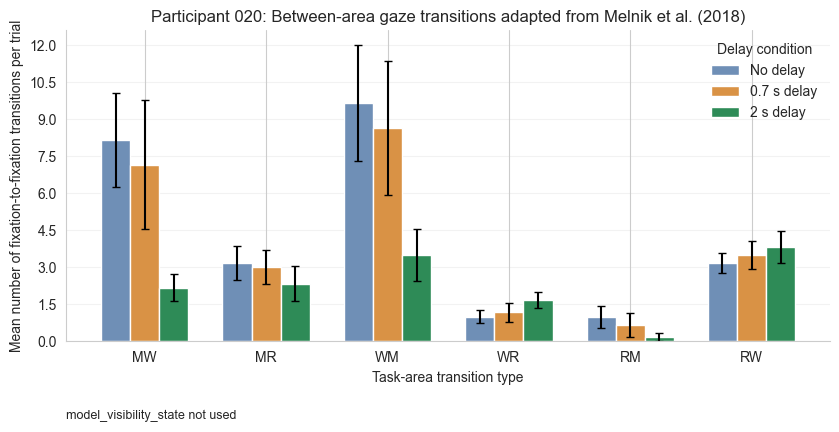

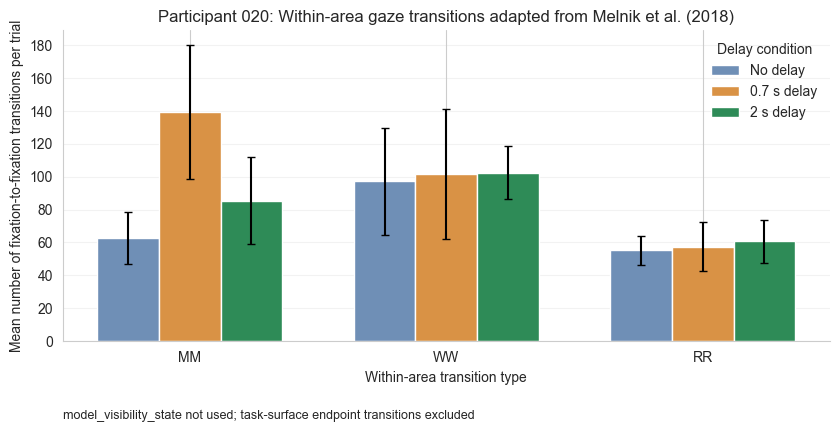

[<Axes: title={'center': 'Participant 020: Between-area gaze transitions adapted from Melnik et al. (2018)'}, xlabel='Task-area transition type', ylabel='Mean number of fixation-to-fixation transitions per trial'>,
 <Axes: title={'center': 'Participant 020: Within-area gaze transitions adapted from Melnik et al. (2018)'}, xlabel='Within-area transition type', ylabel='Mean number of fixation-to-fixation transitions per trial'>]

In [92]:
# Melnik Figure 3-style transition plot for the currently loaded participant.
# Counts transitions between consecutive M/W/R fixation visits, skipping intervening non-task spaces.

MELNIK_PREVIEW_N_TRANSITIONS = 20
MELNIK_TIME_COL = "gaze_capture_time"

MELNIK_CONDITION_LABELS = {
    1: "No delay",
    2: "0.7 s delay",
    3: "2 s delay",
}

MELNIK_AREA_MAP = {
    "model_area": "M",
    "work_area": "W",
    "resource_area": "R",
}

MELNIK_TASK_SURFACE_GROUPS = {
    "model_desk_base",
    "resource_desk_base",
    "work_desk_base",
}

MELNIK_TASK_SURFACE_RAW_NAMES = {
    "Model_plate",
    "ModelFront",
    "ResourceFront",
}

MELNIK_SACCADE_TYPES = [
    "MM", "MW", "MR",
    "WM", "WW", "WR",
    "RM", "RW", "RR",
]


def melnik_most_frequent_first_seen(values):
    """Return the most frequent value, resolving ties by first appearance."""
    values = values.dropna()
    if values.empty:
        return pd.NA

    counts = values.value_counts(sort=False)
    winners = set(counts[counts == counts.max()].index)
    for value in values:
        if value in winners:
            return value
    return pd.NA


def melnik_sem(values):
    """Standard error of the mean, returning 0 for single-trial groups."""
    values = pd.to_numeric(values, errors="coerce").dropna()
    if len(values) <= 1:
        return 0.0
    return values.std(ddof=1) / np.sqrt(len(values))


def melnik_make_fixation_area_events(df, group_cols=GROUP_COLS):
    """Create time-ordered fixation events with dominant gaze_space and M/W/R code."""
    fixation_rows = df[
        df["fixation_id"].notna()
        & df["condition_number"].isin(MELNIK_CONDITION_LABELS)
    ].copy()

    if fixation_rows.empty:
        return pd.DataFrame(columns=[
            *group_cols,
            "fixation_id",
            "fixation_start_ms",
            "fixation_end_ms",
            "fixation_duration_ms",
            "fixation_gaze_space",
            "fixation_area_code",
            "fixation_hit_obj_group",
            "fixation_hit_obj_name",
            "n_fixation_samples",
        ])

    if MELNIK_TIME_COL not in fixation_rows.columns:
        raise KeyError(f"Required ordering column is missing: {MELNIK_TIME_COL}")

    fixation_rows[MELNIK_TIME_COL] = pd.to_numeric(
        fixation_rows[MELNIK_TIME_COL], errors="coerce"
    )
    fixation_rows = fixation_rows.dropna(subset=[MELNIK_TIME_COL])
    # gaze_capture_time is stored in nanoseconds; normalize within each trial.
    trial_start_ns = fixation_rows.groupby(group_cols, dropna=False)[MELNIK_TIME_COL].transform("min")
    fixation_rows["_melnik_time_ms"] = (fixation_rows[MELNIK_TIME_COL] - trial_start_ns) / 1_000_000

    fixation_events = (
        fixation_rows.groupby([*group_cols, "fixation_id"], dropna=False)
        .agg(
            fixation_start_ms=("_melnik_time_ms", "min"),
            fixation_end_ms=("_melnik_time_ms", "max"),
            fixation_duration_ms=("event_duration_ms", melnik_most_frequent_first_seen),
            fixation_gaze_space=("gaze_space", melnik_most_frequent_first_seen),
            fixation_hit_obj_group=("hit_obj_group", melnik_most_frequent_first_seen),
            fixation_hit_obj_name=("hit_obj_name", melnik_most_frequent_first_seen),
            n_fixation_samples=("_melnik_time_ms", "size"),
        )
        .reset_index()
        .sort_values([*group_cols, "fixation_start_ms", "fixation_end_ms"])
        .reset_index(drop=True)
    )

    fixation_events["fixation_area_code"] = fixation_events["fixation_gaze_space"].map(MELNIK_AREA_MAP)
    fixation_events["is_mwr_fixation"] = fixation_events["fixation_area_code"].isin(["M", "W", "R"])
    fixation_events["is_task_surface_fixation"] = (
        fixation_events["fixation_hit_obj_group"].isin(MELNIK_TASK_SURFACE_GROUPS)
        | fixation_events["fixation_hit_obj_name"].isin(MELNIK_TASK_SURFACE_RAW_NAMES)
    )
    fixation_events["trial_fixation_position"] = (
        fixation_events.groupby(group_cols, dropna=False).cumcount()
    )

    return fixation_events


def melnik_make_transition_events(
    fixation_events,
    group_cols=GROUP_COLS,
):
    """Connect consecutive M/W/R visits while skipping intervening non-task fixations."""
    if fixation_events.empty:
        return pd.DataFrame()

    current = fixation_events.loc[fixation_events["is_mwr_fixation"]].copy()
    previous_cols = [
        "fixation_id",
        "fixation_start_ms",
        "fixation_end_ms",
        "fixation_duration_ms",
        "fixation_gaze_space",
        "fixation_area_code",
        "is_task_surface_fixation",
        "trial_fixation_position",
    ]

    for col in previous_cols:
        current[f"from_{col}"] = current.groupby(group_cols, dropna=False)[col].shift()

    transitions = current.rename(columns={
        "fixation_id": "to_fixation_id",
        "fixation_start_ms": "to_fixation_start_ms",
        "fixation_end_ms": "to_fixation_end_ms",
        "fixation_duration_ms": "to_fixation_duration_ms",
        "fixation_gaze_space": "to_gaze_space",
        "fixation_area_code": "to_area",
        "is_task_surface_fixation": "to_is_task_surface_fixation",
        "trial_fixation_position": "to_trial_fixation_position",
    }).copy()

    transitions = transitions.rename(columns={
        "from_fixation_id": "from_fixation_id",
        "from_fixation_start_ms": "from_fixation_start_ms",
        "from_fixation_end_ms": "from_fixation_end_ms",
        "from_fixation_duration_ms": "from_fixation_duration_ms",
        "from_fixation_gaze_space": "from_gaze_space",
        "from_fixation_area_code": "from_area",
        "from_is_task_surface_fixation": "from_is_task_surface_fixation",
        "from_trial_fixation_position": "from_trial_fixation_position",
    })

    transitions = transitions[
        transitions["from_fixation_id"].notna()
        & transitions["to_fixation_id"].notna()
    ].copy()

    transitions["saccade_type"] = transitions["from_area"] + transitions["to_area"]

    transitions["n_intermediate_fixations"] = (
        transitions["to_trial_fixation_position"]
        - transitions["from_trial_fixation_position"]
        - 1
    ).astype(int)
    transitions["crosses_non_task_space"] = transitions["n_intermediate_fixations"].gt(0)
    transitions["is_within_area_transition"] = transitions["from_area"].eq(transitions["to_area"])
    transitions["is_valid_within_area_transition"] = (
        transitions["is_within_area_transition"]
        & ~transitions["from_is_task_surface_fixation"].eq(True)
        & ~transitions["to_is_task_surface_fixation"].eq(True)
    )
    transitions["include_in_figure3"] = (
        ~transitions["is_within_area_transition"]
        | transitions["is_valid_within_area_transition"]
    )
    transitions["time_between_fixations_ms"] = transitions["to_fixation_start_ms"] - transitions["from_fixation_end_ms"]
    transitions["condition_label"] = transitions["condition_number"].map(MELNIK_CONDITION_LABELS)

    keep_cols = [
        *group_cols,
        "condition_label",
        "saccade_type",
        "from_fixation_id",
        "to_fixation_id",
        "from_gaze_space",
        "to_gaze_space",
        "from_area",
        "to_area",
        "from_is_task_surface_fixation",
        "to_is_task_surface_fixation",
        "n_intermediate_fixations",
        "crosses_non_task_space",
        "is_valid_within_area_transition",
        "include_in_figure3",
        "from_fixation_end_ms",
        "to_fixation_start_ms",
        "time_between_fixations_ms",
        "from_fixation_duration_ms",
        "to_fixation_duration_ms",
    ]

    return transitions[keep_cols].reset_index(drop=True)


def melnik_make_transition_trial_counts(transition_events, fixation_events, group_cols=GROUP_COLS):
    """Count transition types per trial, keeping zero-count transition types."""
    if fixation_events.empty:
        return pd.DataFrame(columns=[*group_cols, "saccade_type", "n_saccades"])

    trial_keys = (
        fixation_events.loc[fixation_events["is_mwr_fixation"], group_cols]
        .drop_duplicates()
        .copy()
    )
    type_grid = pd.DataFrame({"saccade_type": MELNIK_SACCADE_TYPES})
    full_grid = (
        trial_keys.assign(_key=1)
        .merge(type_grid.assign(_key=1), on="_key")
        .drop(columns="_key")
    )

    observed_counts = (
        transition_events.loc[transition_events["include_in_figure3"]]
        .groupby([*group_cols, "saccade_type"], dropna=False)
        .size()
        .rename("n_saccades")
        .reset_index()
    )

    return (
        full_grid.merge(observed_counts, on=[*group_cols, "saccade_type"], how="left")
        .assign(n_saccades=lambda x: x["n_saccades"].fillna(0).astype(int))
    )


def melnik_make_transition_summary(transition_trial_counts):
    """Summarize transition counts as mean +/- SEM per trial for each condition."""
    if transition_trial_counts.empty:
        return pd.DataFrame(columns=["condition_number", "saccade_type", "mean_saccades", "sem_saccades", "n_trials"])

    summary = (
        transition_trial_counts.groupby(["condition_number", "saccade_type"], dropna=False)
        .agg(
            mean_saccades=("n_saccades", "mean"),
            sem_saccades=("n_saccades", melnik_sem),
            n_trials=("n_saccades", "size"),
        )
        .reset_index()
    )
    summary["condition_label"] = summary["condition_number"].map(MELNIK_CONDITION_LABELS)
    return summary


def plot_melnik_figure3_style(summary):
    """Plot Melnik-inspired transition counts in two scales."""
    if summary.empty:
        print("No transition summary available for plotting.")
        return None

    condition_numbers = [cond for cond in MELNIK_CONDITION_LABELS if cond in set(summary["condition_number"])]
    colors = ["#6F8FB6", "#D99245", "#2E8B57"]

    plot_groups = [
        (
            ["MW", "MR", "WM", "WR", "RM", "RW"],
            "Between-area gaze transitions adapted from Melnik et al. (2018)",
            "Task-area transition type",
        ),
        (
            ["MM", "WW", "RR"],
            "Within-area gaze transitions adapted from Melnik et al. (2018)",
            "Within-area transition type",
        ),
    ]

    axes = []
    note = "model_visibility_state not used"

    for transition_types, title, xlabel in plot_groups:
        x = np.arange(len(transition_types))
        bar_width = 0.24 if len(condition_numbers) == 3 else 0.32
        plot_note = note
        if transition_types == ["MM", "WW", "RR"]:
            plot_note += "; task-surface endpoint transitions excluded"

        fig, ax = plt.subplots(figsize=(8.5, 4.5))

        for i, cond in enumerate(condition_numbers):
            cond_summary = (
                summary[summary["condition_number"].eq(cond)]
                .set_index("saccade_type")
                .reindex(transition_types)
            )
            means = cond_summary["mean_saccades"].fillna(0).to_numpy(dtype=float)
            sems = cond_summary["sem_saccades"].fillna(0).to_numpy(dtype=float)
            offset = (i - (len(condition_numbers) - 1) / 2) * bar_width

            ax.bar(
                x + offset,
                means,
                width=bar_width,
                yerr=sems,
                capsize=3,
                color=colors[i % len(colors)],
                edgecolor="white",
                linewidth=1.0,
                label=MELNIK_CONDITION_LABELS[cond],
            )

        ax.set_title(f"Participant {PARTICIPANT_ID}: {title}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Mean number of fixation-to-fixation transitions per trial")
        ax.set_xticks(x)
        ax.set_xticklabels(transition_types)
        ax.yaxis.set_major_locator(MaxNLocator(integer=False))
        ax.grid(axis="y", alpha=0.25)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(title="Delay condition", frameon=False)
        ax.text(0.0, -0.22, plot_note, transform=ax.transAxes, ha="left", va="top", fontsize=9)

        plt.tight_layout()
        plt.show()
        axes.append(ax)

    return axes


melnik_fixation_area_events = melnik_make_fixation_area_events(df)
melnik_transition_events = melnik_make_transition_events(melnik_fixation_area_events)
melnik_transition_trial_counts = melnik_make_transition_trial_counts(
    melnik_transition_events,
    melnik_fixation_area_events,
)
melnik_transition_summary = melnik_make_transition_summary(melnik_transition_trial_counts)

melnik_transition_mean_table = (
    melnik_transition_summary.pivot(
        index="saccade_type",
        columns="condition_label",
        values="mean_saccades",
    )
    .reindex(MELNIK_SACCADE_TYPES)
)

melnik_transition_sem_table = (
    melnik_transition_summary.pivot(
        index="saccade_type",
        columns="condition_label",
        values="sem_saccades",
    )
    .reindex(MELNIK_SACCADE_TYPES)
)

print(f"Analysis scope: participant {PARTICIPANT_ID}")
print(f"M/W/R fixation events: {melnik_fixation_area_events['is_mwr_fixation'].sum():,}")
print(f"M/W/R transitions counted: {len(melnik_transition_events):,}")
print(f"Transitions included in plots: {melnik_transition_events['include_in_figure3'].sum():,}")
print(f"Within-area transitions removed for surface endpoints: {(~melnik_transition_events['include_in_figure3']).sum():,}")
print(f"Transitions crossing intermediate non-task fixations: {melnik_transition_events['crosses_non_task_space'].sum():,}")
print(f"Trials summarized: {melnik_transition_trial_counts[GROUP_COLS].drop_duplicates().shape[0]:,}")

print("Transition event preview for checking detection:")
display(melnik_transition_events.head(MELNIK_PREVIEW_N_TRANSITIONS))

print("Transition counts by condition:")
display(
    melnik_transition_events.loc[melnik_transition_events["include_in_figure3"]]
    .groupby(["condition_label", "saccade_type"], dropna=False)
    .size()
    .rename("n_transitions")
    .reset_index()
    .pivot(index="saccade_type", columns="condition_label", values="n_transitions")
    .reindex(MELNIK_SACCADE_TYPES)
    .fillna(0)
    .astype(int)
)

print("Mean transitions per trial:")
display(melnik_transition_mean_table.round(2))
print("SEM transitions per trial:")
display(melnik_transition_sem_table.round(2))

plot_melnik_figure3_style(melnik_transition_summary)






## 9.2 Delay Behavior: Melnik Figure 5-Style Summary

This section adapts the structure of Melnik et al.'s Figure 5 for the currently loaded participant.

Panel A shows returns to the model area from:

- `WM`: work area -> model area
- `RM`: resource area -> model area

The transitions use the collapsed task-area logic from section 9.1. This means intermediate non-task fixations are skipped: for example, `work_area -> room -> model_area` is counted as `WM`, and `resource_area -> room -> model_area` is counted as `RM`.

Panel B shows the total number of M/W/R task-area transitions per trial, using the same nine transition types as section 9.1. Panel C shows trial duration from `time_ms`, computed as `max(time_ms) - min(time_ms)` within each valid `(participant_id, condition_number, trial_number)` group.

No `model_visibility_state` information is used in this figure.



Panel A: model-area returns per trial


,condition_number,WM,RM,model_area_returns,sem,n_trials,condition_label
0,1,9.67,1.00,10.67,2.73,6,No delay
1,2,8.67,0.67,9.33,3.16,6,0.7 s delay
2,3,3.50,0.17,3.67,1.17,6,2 s delay


Panel B: total task-area transitions per trial


,condition_number,mean,sem,n_trials,condition_label
0,1,241.00,58.69,6,No delay
1,2,322.67,99.35,6,0.7 s delay
2,3,262.50,55.46,6,2 s delay


Panel C: trial duration in seconds


,condition_number,mean,sem,n_trials,condition_label
0,1,90.00,18.96,6,No delay
1,2,101.67,29.56,6,0.7 s delay
2,3,84.82,17.59,6,2 s delay


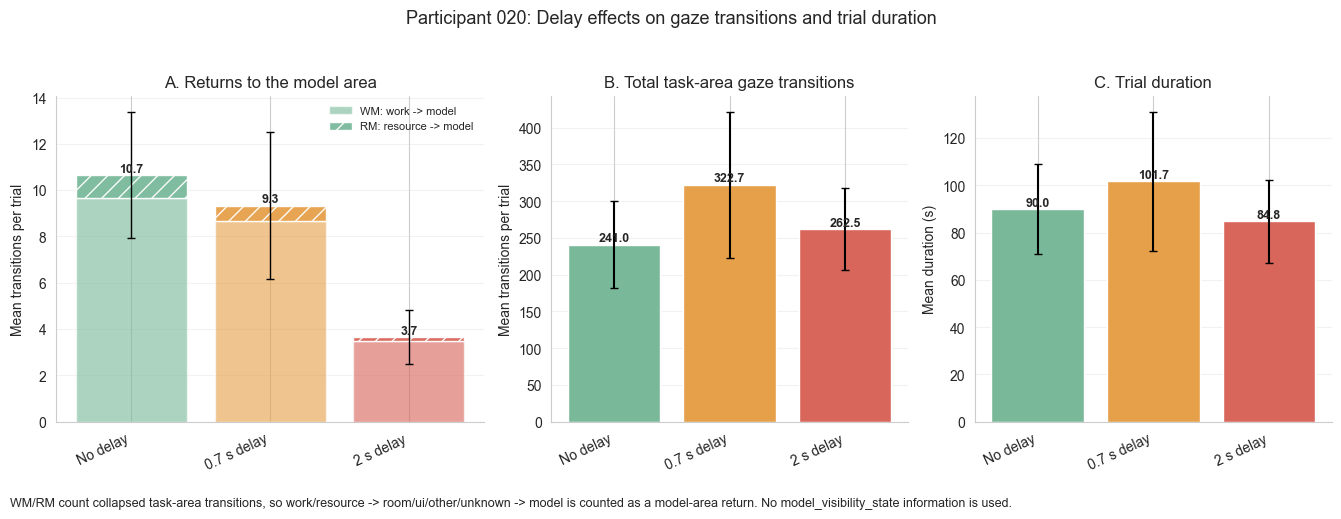

array([<Axes: title={'center': 'A. Returns to the model area'}, ylabel='Mean transitions per trial'>,
       <Axes: title={'center': 'B. Total task-area gaze transitions'}, ylabel='Mean transitions per trial'>,
       <Axes: title={'center': 'C. Trial duration'}, ylabel='Mean duration (s)'>],
      dtype=object)

In [93]:
# Melnik Figure 5-style summary for the currently loaded participant.
# Uses the transition table from section 9.1 and trial durations from time_ms.

MELNIK_FIG5_CONDITION_COLORS = {
    1: "#79B99A",  # soft green: no delay
    2: "#E6A04A",  # amber: short delay
    3: "#D8665B",  # muted red: long delay
}


def melnik_fig5_trial_tables(df, transition_trial_counts, group_cols=GROUP_COLS):
    """Create trial-level tables for Figure 5-style panels A, B, and C."""
    trial_keys = (
        transition_trial_counts[group_cols]
        .drop_duplicates()
        .sort_values(group_cols)
        .reset_index(drop=True)
    )

    model_return_counts = (
        transition_trial_counts[transition_trial_counts["saccade_type"].isin(["WM", "RM"])]
        .pivot_table(
            index=group_cols,
            columns="saccade_type",
            values="n_saccades",
            aggfunc="sum",
            fill_value=0,
        )
        .reset_index()
    )
    for col in ["WM", "RM"]:
        if col not in model_return_counts.columns:
            model_return_counts[col] = 0
    model_return_counts = trial_keys.merge(model_return_counts, on=group_cols, how="left").fillna({"WM": 0, "RM": 0})
    model_return_counts["model_area_returns"] = model_return_counts["WM"] + model_return_counts["RM"]

    total_transition_counts = (
        transition_trial_counts.groupby(group_cols, dropna=False)["n_saccades"]
        .sum()
        .rename("total_task_area_transitions")
        .reset_index()
    )

    valid_rows = df[df["condition_number"].isin(MELNIK_CONDITION_LABELS)].copy()
    valid_rows["time_ms"] = pd.to_numeric(valid_rows["time_ms"], errors="coerce")
    trial_durations = (
        valid_rows.dropna(subset=["time_ms"])
        .groupby(group_cols, dropna=False)
        .agg(
            trial_start_ms=("time_ms", "min"),
            trial_end_ms=("time_ms", "max"),
            n_samples=("time_ms", "size"),
        )
        .reset_index()
    )
    trial_durations["trial_duration_s"] = (
        trial_durations["trial_end_ms"] - trial_durations["trial_start_ms"]
    ) / 1000

    return model_return_counts, total_transition_counts, trial_durations


def melnik_fig5_mean_sem(table, value_col):
    """Mean and SEM per condition for one trial-level value."""
    summary = (
        table.groupby("condition_number", dropna=False)[value_col]
        .agg(mean="mean", sem=melnik_sem, n_trials="size")
        .reset_index()
    )
    summary["condition_label"] = summary["condition_number"].map(MELNIK_CONDITION_LABELS)
    return summary


def melnik_fig5_component_summary(model_return_counts):
    """Mean WM/RM model-area returns plus SEM for their total."""
    component = (
        model_return_counts.groupby("condition_number", dropna=False)[["WM", "RM", "model_area_returns"]]
        .mean()
        .reset_index()
    )
    total_sem = melnik_fig5_mean_sem(model_return_counts, "model_area_returns")[["condition_number", "sem", "n_trials"]]
    component = component.merge(total_sem, on="condition_number", how="left")
    component["condition_label"] = component["condition_number"].map(MELNIK_CONDITION_LABELS)
    return component


def plot_melnik_figure5_style(model_return_counts, total_transition_counts, trial_durations):
    """Plot a three-panel Melnik Figure 5-style summary."""
    condition_numbers = [cond for cond in MELNIK_CONDITION_LABELS if cond in set(model_return_counts["condition_number"])]
    condition_labels = [MELNIK_CONDITION_LABELS[cond] for cond in condition_numbers]
    colors = [MELNIK_FIG5_CONDITION_COLORS[cond] for cond in condition_numbers]
    x = np.arange(len(condition_numbers))

    model_return_summary = melnik_fig5_component_summary(model_return_counts).set_index("condition_number")
    total_transition_summary = melnik_fig5_mean_sem(total_transition_counts, "total_task_area_transitions").set_index("condition_number")
    duration_summary = melnik_fig5_mean_sem(trial_durations, "trial_duration_s").set_index("condition_number")

    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6), gridspec_kw={"width_ratios": [1.2, 1, 1]})
    fig.suptitle(
        f"Participant {PARTICIPANT_ID}: Delay effects on gaze transitions and trial duration",
        y=1.04,
        fontsize=13,
    )

    # Panel A: stacked WM/RM model-area returns.
    ax = axes[0]
    wm_means = model_return_summary.reindex(condition_numbers)["WM"].fillna(0).to_numpy(dtype=float)
    rm_means = model_return_summary.reindex(condition_numbers)["RM"].fillna(0).to_numpy(dtype=float)
    total_means = model_return_summary.reindex(condition_numbers)["model_area_returns"].fillna(0).to_numpy(dtype=float)
    total_sems = model_return_summary.reindex(condition_numbers)["sem"].fillna(0).to_numpy(dtype=float)

    ax.bar(x, wm_means, color=colors, alpha=0.62, edgecolor="white", linewidth=1.0, label="WM: work -> model")
    ax.bar(x, rm_means, bottom=wm_means, color=colors, alpha=0.95, edgecolor="white", linewidth=1.0, hatch="//", label="RM: resource -> model")
    ax.errorbar(x, total_means, yerr=total_sems, fmt="none", ecolor="black", capsize=3, lw=1)
    for xpos, total in zip(x, total_means):
        ax.text(xpos, total, f"{total:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title("A. Returns to the model area")
    ax.set_ylabel("Mean transitions per trial")
    ax.set_xticks(x)
    ax.set_xticklabels(condition_labels, rotation=25, ha="right")
    ax.legend(frameon=False, fontsize=8)

    # Panel B: total task-area transitions.
    ax = axes[1]
    means = total_transition_summary.reindex(condition_numbers)["mean"].fillna(0).to_numpy(dtype=float)
    sems = total_transition_summary.reindex(condition_numbers)["sem"].fillna(0).to_numpy(dtype=float)
    ax.bar(x, means, yerr=sems, capsize=3, color=colors, edgecolor="white", linewidth=1.0)
    for xpos, mean in zip(x, means):
        ax.text(xpos, mean, f"{mean:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title("B. Total task-area gaze transitions")
    ax.set_ylabel("Mean transitions per trial")
    ax.set_xticks(x)
    ax.set_xticklabels(condition_labels, rotation=25, ha="right")

    # Panel C: trial duration.
    ax = axes[2]
    means = duration_summary.reindex(condition_numbers)["mean"].fillna(0).to_numpy(dtype=float)
    sems = duration_summary.reindex(condition_numbers)["sem"].fillna(0).to_numpy(dtype=float)
    ax.bar(x, means, yerr=sems, capsize=3, color=colors, edgecolor="white", linewidth=1.0)
    for xpos, mean in zip(x, means):
        ax.text(xpos, mean, f"{mean:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title("C. Trial duration")
    ax.set_ylabel("Mean duration (s)")
    ax.set_xticks(x)
    ax.set_xticklabels(condition_labels, rotation=25, ha="right")

    for ax in axes:
        ax.grid(axis="y", alpha=0.25)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_axisbelow(True)

    fig.text(
        0.01,
        -0.04,
        "WM/RM count collapsed task-area transitions, so work/resource -> room/ui/other/unknown -> model is counted as a model-area return. "
        "No model_visibility_state information is used.",
        ha="left",
        fontsize=9,
    )

    plt.tight_layout()
    plt.show()
    return axes


melnik_fig5_model_return_counts, melnik_fig5_total_transition_counts, melnik_fig5_trial_durations = melnik_fig5_trial_tables(
    df,
    melnik_transition_trial_counts,
)

melnik_fig5_model_return_summary = melnik_fig5_component_summary(melnik_fig5_model_return_counts)
melnik_fig5_total_transition_summary = melnik_fig5_mean_sem(
    melnik_fig5_total_transition_counts,
    "total_task_area_transitions",
)
melnik_fig5_trial_duration_summary = melnik_fig5_mean_sem(
    melnik_fig5_trial_durations,
    "trial_duration_s",
)

print("Panel A: model-area returns per trial")
display(melnik_fig5_model_return_summary.round(2))
print("Panel B: total task-area transitions per trial")
display(melnik_fig5_total_transition_summary.round(2))
print("Panel C: trial duration in seconds")
display(melnik_fig5_trial_duration_summary.round(2))

plot_melnik_figure5_style(
    melnik_fig5_model_return_counts,
    melnik_fig5_total_transition_counts,
    melnik_fig5_trial_durations,
)



In [11]:
df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,hit_obj_group,gaze_space,saccade_id,fixation_id,event_duration_ms,fixation_target,lefthand_grab_id,righthand_grab_id,fixation_target_dominance_ratio,fixation_n_unique_targets
0,1000001842383524100,1778585510583,670.642,0.779764,260247,1.000000,Valid,0.015151,0.081672,0.996544,...,walls,room,<NA>,1,280.0392,walls,<NA>,<NA>,1.0,1
1,1000001842388531500,1778585510583,670.642,0.779619,260248,1.000000,Valid,0.015269,0.081883,0.996525,...,walls,room,<NA>,1,280.0392,walls,<NA>,<NA>,1.0,1
2,1000001842393529400,1778585510583,670.642,0.779649,260249,1.000000,Valid,0.015373,0.082076,0.996507,...,walls,room,<NA>,1,280.0392,walls,<NA>,<NA>,1.0,1
3,1000001842398528200,1778585510583,670.642,0.779441,260250,1.000000,Valid,0.015460,0.082254,0.996491,...,walls,room,<NA>,1,280.0392,walls,<NA>,<NA>,1.0,1
4,1000001842403528200,1778585510583,670.642,0.779066,260251,1.000000,Valid,0.015521,0.082415,0.996477,...,walls,room,<NA>,1,280.0392,walls,<NA>,<NA>,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258897,1000004463788356000,1778588131990,2788.418,0.574843,784326,0.679744,Valid,0.171224,-0.192664,0.966211,...,ui,ui,<NA>,5959,435.0522,ui,<NA>,72,1.0,1
258898,1000004463793357100,1778588131990,2788.418,0.575592,784327,0.775588,Valid,0.171051,-0.192243,0.966325,...,ui,ui,<NA>,5959,435.0522,ui,<NA>,72,1.0,1
258899,1000004463798356400,1778588131990,2788.418,0.576194,784328,0.804346,Valid,0.170920,-0.191830,0.966430,...,ui,ui,<NA>,5959,435.0522,ui,<NA>,72,1.0,1
258900,1000004463803355400,1778588131990,2788.418,0.576437,784329,0.805834,Valid,0.170844,-0.191464,0.966517,...,ui,ui,<NA>,5959,435.0522,ui,<NA>,72,1.0,1


In [12]:
df["condition_number"].value_counts()

condition_number
3    96582
2    91756
1    70564
Name: count, dtype: int64

In [20]:
df["model_visibility_state"].value_counts()

model_visibility_state
0    190976
1     67926
Name: count, dtype: int64

In [94]:
df["gaze_space"].value_counts()

gaze_space
work_area        121656
model_area       106685
resource_area     61198
room              13517
ui                 9224
other              6207
unknown            1139
Name: count, dtype: int64

## 9.3 Grab Match Within Last 5 Model-Brick Fixations

For each brick grab, this analysis looks backward within the same participant, condition, and trial. It checks whether the grabbed brick appears in the last five previous model-brick fixations, where a model-brick fixation is defined as:

- `fixation_target` starts with `temp_`
- the fixation is in `model_area` according to sample-level `gaze_space`

A grab is marked as a match when the grabbed brick ID appears among those five model-brick fixation IDs. This version does not apply a time-window limit; set `MATCH_WINDOW_MS` to a number if you later want to add one. `gaze_space` remains sample-level; the fixation table below only uses it to decide whether each fixation belonged to the model area.




Brick grab events: 101
Match window: no time limit
Previous model-brick fixations checked per grab: 5


,grab_hand,condition_number,trial_number,grab_start_ms,grabbed_object,grabbed_brick_id,previous_fixation_target,previous_fixation_brick_id,previous_model_fixation_brick_ids,time_since_previous_fixation_ms,grab_matches_previous_model_fixation
0,right,1,1,9428.1977,brick_2x4_pink_res_029,29,temp_027,27,"[27, 29, 29, 28, 27]",3311.4221,True
1,left,1,1,9938.2622,brick_2x4_green_res_027,27,temp_027,27,"[27, 29, 29, 28, 27]",3821.4866,True
2,right,1,2,6652.8388,brick_2x4_pink_res_064,64,temp_064,64,"[64, 64, 64, 64, 64]",2185.2733,True
3,left,1,2,7352.9296,brick_2x4_pink_res_060,60,temp_064,64,"[64, 64, 64, 64, 64]",2885.3641,False
4,left,1,2,9179.1667,brick_2x2_yellow_res_062,62,temp_063,63,"[63, 63, 63, 63, 63]",55.0152,False
5,left,1,3,6426.8177,brick_1x3_yellow_res_069,69,temp_073,73,"[73, 73, 71, 73, 73]",1970.2465,False
6,right,1,3,7057.8991,brick_1x3_pink_res_075,75,temp_073,73,"[73, 73, 71, 73, 73]",2601.3279,False
7,right,1,4,5246.6574,brick_2x2_pink_res_021,21,temp_022,22,"[22, 22, 21]",2676.3422,True
8,left,1,4,5756.7256,brick_2x2_green_res_024,24,temp_022,22,"[22, 22, 21]",3186.4104,False
9,left,1,4,7777.9837,brick_2x2_green_res_022,22,temp_022,22,"[22, 22, 21]",5207.6685,True


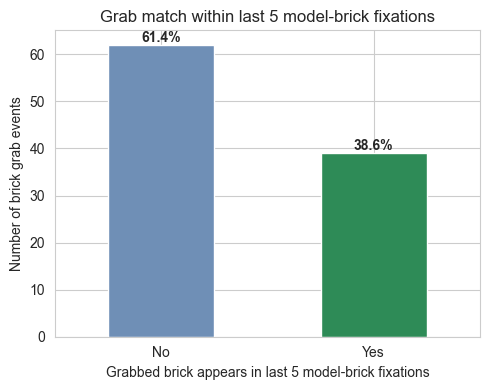

Last 5 model-brick fixations before preview grab:
Preview grab: hand=right, grabbed=brick_2x4_pink_res_029, brick_id=29


,fixation_id,fixation_end_ms,fixation_target,fixation_brick_id,time_since_fixation_ms,fixation_target_dominance_ratio,fixation_n_unique_targets
23,24,6116.7756,temp_027,27,3311.4221,0.722222,2
22,23,5976.7635,temp_029,29,3451.4342,1.000000,1
21,22,5541.7051,temp_029,29,3886.4926,1.000000,1
20,21,5111.6483,temp_028,28,4316.5494,1.000000,1
19,20,4946.6305,temp_027,27,4481.5672,1.000000,1


In [10]:
MATCH_WINDOW_MS = None
N_PREVIOUS_MODEL_FIXATIONS = 5
PREVIEW_MATCH_ROW = 0


def extract_brick_id(value):
    """Extract a LEGO brick ID from grouped or raw object names."""
    if pd.isna(value):
        return pd.NA

    match = re.search(r"(?:^|_)(?:temp|res|dis)_(\d+)$", str(value), flags=re.IGNORECASE)
    if match:
        return str(int(match.group(1)))
    return pd.NA


def first_non_missing(values):
    values = values.dropna()
    return values.iloc[0] if len(values) else pd.NA


def most_frequent_first_seen(values):
    values = values.dropna()
    if values.empty:
        return pd.NA
    counts = values.value_counts(sort=False)
    winners = set(counts[counts == counts.max()].index)
    for value in values:
        if value in winners:
            return value
    return pd.NA


def make_fixation_events(
    df,
    group_cols=GROUP_COLS,
    fixation_col="fixation_id",
    time_col="time_ms",
):
    """Create one row per fixation, including model-area and brick identity summaries."""
    fixation_rows = df[df[fixation_col].notna()].copy()
    group_keys = [*group_cols, fixation_col]

    events = (
        fixation_rows.groupby(group_keys, dropna=False)
        .agg(
            fixation_start_ms=(time_col, "min"),
            fixation_end_ms=(time_col, "max"),
            fixation_duration_ms=("event_duration_ms", first_non_missing),
            fixation_target=("fixation_target", first_non_missing),
            fixation_target_dominance_ratio=("fixation_target_dominance_ratio", first_non_missing),
            fixation_n_unique_targets=("fixation_n_unique_targets", first_non_missing),
            fixation_gaze_space=("gaze_space", most_frequent_first_seen),
            model_area_sample_ratio=("gaze_space", lambda s: s.eq("model_area").mean()),
            n_fixation_samples=(time_col, "size"),
        )
        .reset_index()
    )

    events["fixation_brick_id"] = events["fixation_target"].apply(extract_brick_id)
    events["is_model_brick_fixation"] = (
        events["fixation_target"].astype("string").str.startswith("temp_", na=False)
        & events["fixation_gaze_space"].eq("model_area")
        & events["fixation_brick_id"].notna()
    )

    return events


def make_grab_events(
    df,
    group_cols=GROUP_COLS,
    time_col="time_ms",
):
    """Create one row per left/right grab event."""
    grab_event_tables = []

    for hand, grabbed_col, grab_id_col in [
        ("left", LEFT_GRABBED_COL, "lefthand_grab_id"),
        ("right", RIGHT_GRABBED_COL, "righthand_grab_id"),
    ]:
        hand_rows = df[df[grab_id_col].notna()].copy()
        if hand_rows.empty:
            continue

        events = (
            hand_rows.groupby([*group_cols, grab_id_col], dropna=False)
            .agg(
                grab_start_ms=(time_col, "min"),
                grab_end_ms=(time_col, "max"),
                grabbed_object=(grabbed_col, most_frequent_first_seen),
                n_grab_samples=(time_col, "size"),
            )
            .reset_index()
            .rename(columns={grab_id_col: "grab_id"})
        )

        events["grab_hand"] = hand
        events["grab_duration_ms"] = events["grab_end_ms"] - events["grab_start_ms"]
        events["grabbed_brick_id"] = events["grabbed_object"].apply(extract_brick_id)
        grab_event_tables.append(events)

    if not grab_event_tables:
        return pd.DataFrame()

    return pd.concat(grab_event_tables, ignore_index=True).sort_values(
        [*group_cols, "grab_start_ms", "grab_hand"]
    )


def get_previous_model_brick_fixations(
    fixation_events,
    grab_row,
    group_cols=GROUP_COLS,
    window_ms=MATCH_WINDOW_MS,
):
    """Return model-brick fixations before one grab, newest first."""
    same_trial = pd.Series(True, index=fixation_events.index)
    for col in group_cols:
        same_trial &= fixation_events[col].eq(grab_row[col])

    before_grab = fixation_events["fixation_end_ms"].le(grab_row["grab_start_ms"])
    candidates = fixation_events[same_trial & before_grab & fixation_events["is_model_brick_fixation"]].copy()

    candidates["time_since_fixation_ms"] = grab_row["grab_start_ms"] - candidates["fixation_end_ms"]
    if window_ms is not None:
        candidates = candidates[candidates["time_since_fixation_ms"].le(window_ms)]

    return candidates.sort_values("fixation_end_ms", ascending=False)


def make_grab_fixation_matches(
    grab_events,
    fixation_events,
    group_cols=GROUP_COLS,
    window_ms=MATCH_WINDOW_MS,
    n_previous_fixations=N_PREVIOUS_MODEL_FIXATIONS,
):
    """Match each brick grab against the last N previous model-brick fixations."""
    match_columns = list(grab_events.columns) + [
        "has_previous_model_brick_fixation",
        "previous_fixation_id",
        "previous_fixation_target",
        "previous_fixation_brick_id",
        "previous_fixation_end_ms",
        "time_since_previous_fixation_ms",
        "previous_fixation_dominance_ratio",
        "previous_fixation_n_unique_targets",
        "previous_model_fixation_targets",
        "previous_model_fixation_brick_ids",
        "n_previous_model_brick_fixations_checked",
        "grab_matches_previous_model_fixation",
    ]

    if grab_events.empty or "grabbed_brick_id" not in grab_events.columns:
        return pd.DataFrame(columns=match_columns)

    brick_grabs = grab_events[grab_events["grabbed_brick_id"].notna()].copy()
    rows = []

    for _, grab in brick_grabs.iterrows():
        previous_fixations = get_previous_model_brick_fixations(
            fixation_events,
            grab,
            group_cols=group_cols,
            window_ms=window_ms,
        )
        previous_fixations_to_check = previous_fixations.head(n_previous_fixations)
        previous = previous_fixations_to_check.iloc[0] if len(previous_fixations_to_check) else None
        previous_brick_ids = previous_fixations_to_check["fixation_brick_id"].dropna().astype(str).tolist()
        previous_targets = previous_fixations_to_check["fixation_target"].dropna().astype(str).tolist()

        row = grab.to_dict()
        row["has_previous_model_brick_fixation"] = previous is not None

        if previous is None:
            row.update({
                "previous_fixation_id": pd.NA,
                "previous_fixation_target": pd.NA,
                "previous_fixation_brick_id": pd.NA,
                "previous_fixation_end_ms": pd.NA,
                "time_since_previous_fixation_ms": pd.NA,
                "previous_fixation_dominance_ratio": pd.NA,
                "previous_fixation_n_unique_targets": pd.NA,
                "previous_model_fixation_targets": [],
                "previous_model_fixation_brick_ids": [],
                "n_previous_model_brick_fixations_checked": 0,
            })
            row["grab_matches_previous_model_fixation"] = False
        else:
            row.update({
                "previous_fixation_id": previous["fixation_id"],
                "previous_fixation_target": previous["fixation_target"],
                "previous_fixation_brick_id": previous["fixation_brick_id"],
                "previous_fixation_end_ms": previous["fixation_end_ms"],
                "time_since_previous_fixation_ms": previous["time_since_fixation_ms"],
                "previous_fixation_dominance_ratio": previous["fixation_target_dominance_ratio"],
                "previous_fixation_n_unique_targets": previous["fixation_n_unique_targets"],
                "previous_model_fixation_targets": previous_targets,
                "previous_model_fixation_brick_ids": previous_brick_ids,
                "n_previous_model_brick_fixations_checked": len(previous_fixations_to_check),
            })
            row["grab_matches_previous_model_fixation"] = str(row["grabbed_brick_id"]) in previous_brick_ids

        rows.append(row)

    return pd.DataFrame(rows, columns=match_columns)


fixation_events = make_fixation_events(df)
grab_events = make_grab_events(df)
grab_fixation_matches = make_grab_fixation_matches(
    grab_events,
    fixation_events,
    window_ms=MATCH_WINDOW_MS,
    n_previous_fixations=N_PREVIOUS_MODEL_FIXATIONS,
)

match_counts = (
    grab_fixation_matches.assign(
        match_label=lambda x: np.where(x["grab_matches_previous_model_fixation"], "Yes", "No")
    )
    .groupby("match_label")
    .size()
    .reindex(["No", "Yes"], fill_value=0)
)

display_cols = [
    "grab_hand",
    "condition_number",
    "trial_number",
    "grab_start_ms",
    "grabbed_object",
    "grabbed_brick_id",
    "previous_fixation_target",
    "previous_fixation_brick_id",
    "previous_model_fixation_brick_ids",
    "time_since_previous_fixation_ms",
    "grab_matches_previous_model_fixation",
]

print(f"Brick grab events: {len(grab_fixation_matches):,}")
print("Match window: no time limit" if MATCH_WINDOW_MS is None else f"Match window: {MATCH_WINDOW_MS} ms")
print(f"Previous model-brick fixations checked per grab: {N_PREVIOUS_MODEL_FIXATIONS}")
display(grab_fixation_matches[display_cols].head(10))

ax = match_counts.plot(kind="bar", figsize=(5, 4), color=["#6F8FB6", "#2E8B57"], rot=0)
ax.set_title("Grab match within last 5 model-brick fixations")
ax.set_xlabel("Grabbed brick appears in last 5 model-brick fixations")
ax.set_ylabel("Number of brick grab events")

total = match_counts.sum()
for patch in ax.patches:
    count = int(patch.get_height())
    pct = 100 * count / total if total else 0
    ax.annotate(
        f"{pct:.1f}%",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

if len(grab_fixation_matches):
    preview_grab = grab_fixation_matches.iloc[PREVIEW_MATCH_ROW]
    last_5_model_brick_fixations = get_previous_model_brick_fixations(
        fixation_events,
        preview_grab,
        window_ms=None,
    ).head(5)

    print("Last 5 model-brick fixations before preview grab:")
    print(
        f"Preview grab: hand={preview_grab['grab_hand']}, "
        f"grabbed={preview_grab['grabbed_object']}, "
        f"brick_id={preview_grab['grabbed_brick_id']}"
    )
    display(
        last_5_model_brick_fixations[[
            "fixation_id",
            "fixation_end_ms",
            "fixation_target",
            "fixation_brick_id",
            "time_since_fixation_ms",
            "fixation_target_dominance_ratio",
            "fixation_n_unique_targets",
        ]]
    )


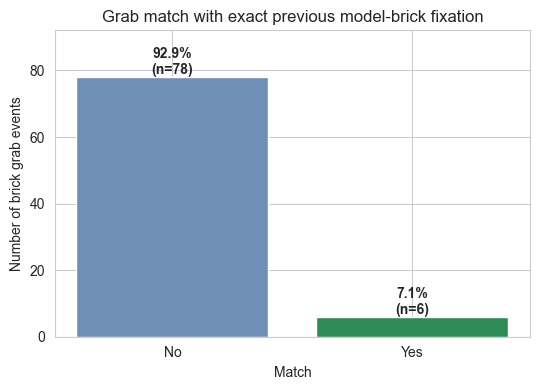

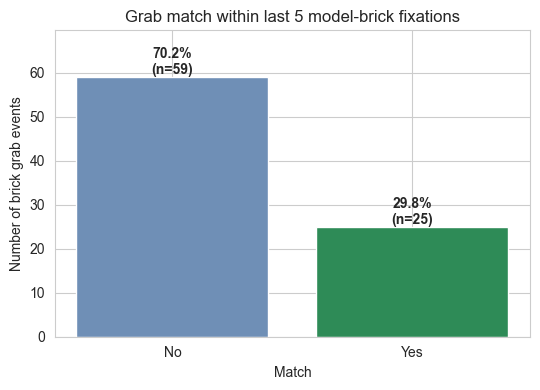

In [53]:
# Compare exact-last versus last-five model-brick fixation matches.
# This cell keeps the earlier pipeline unchanged and only creates the two requested plots.

RQ_RESOURCE_FOOT_AREAS = {"Resource", "Middle"}
RQ_N_PREVIOUS_FIXATIONS = 5


def rq_extract_brick_id(value):
    """Extract brick ID from grouped names like temp_121 or raw names like brick_1x3_pink_res_121."""
    if pd.isna(value):
        return pd.NA

    match = re.search(r"(?:^|_)(?:temp|res|dis)_(\d+)$", str(value), flags=re.IGNORECASE)
    if match:
        return str(int(match.group(1)))
    return pd.NA


def rq_first_non_missing(values):
    values = values.dropna()
    return values.iloc[0] if len(values) else pd.NA


def rq_most_frequent_first_seen(values):
    values = values.dropna()
    if values.empty:
        return pd.NA

    counts = values.value_counts(sort=False)
    winners = set(counts[counts == counts.max()].index)
    for value in values:
        if value in winners:
            return value
    return pd.NA


def rq_make_fixation_events(df, group_cols=GROUP_COLS):
    """One row per fixation, limited later to model-area template-brick fixations."""
    fixation_rows = df[df["fixation_id"].notna()].copy()

    fixation_events = (
        fixation_rows.groupby([*group_cols, "fixation_id"], dropna=False)
        .agg(
            fixation_start_ms=("time_ms", "min"),
            fixation_end_ms=("time_ms", "max"),
            fixation_target=("fixation_target", rq_first_non_missing),
            fixation_gaze_space=("gaze_space", rq_most_frequent_first_seen),
            fixation_target_dominance_ratio=("fixation_target_dominance_ratio", rq_first_non_missing),
            fixation_n_unique_targets=("fixation_n_unique_targets", rq_first_non_missing),
        )
        .reset_index()
    )

    fixation_events["fixation_brick_id"] = fixation_events["fixation_target"].apply(rq_extract_brick_id)
    fixation_events["is_model_brick_fixation"] = (
        fixation_events["fixation_target"].astype("string").str.startswith("temp_", na=False)
        & fixation_events["fixation_gaze_space"].eq("model_area")
        & fixation_events["fixation_brick_id"].notna()
    )

    return fixation_events


def rq_make_resource_grab_events(df, group_cols=GROUP_COLS):
    """One row per left/right brick grab while the matching foot is in Resource or Middle."""
    grab_tables = []

    hand_specs = [
        ("left", "lefthand_grab_id", LEFT_GRABBED_COL, "LeftFootArea"),
        ("right", "righthand_grab_id", RIGHT_GRABBED_COL, "RightFootArea"),
    ]

    for hand, grab_id_col, grabbed_col, foot_area_col in hand_specs:
        if grab_id_col not in df.columns or grabbed_col not in df.columns or foot_area_col not in df.columns:
            continue

        grab_rows = df[df[grab_id_col].notna()].copy()
        if grab_rows.empty:
            continue

        grab_events = (
            grab_rows.groupby([*group_cols, grab_id_col], dropna=False)
            .agg(
                grab_start_ms=("time_ms", "min"),
                grab_end_ms=("time_ms", "max"),
                grabbed_object=(grabbed_col, rq_most_frequent_first_seen),
                grab_foot_area=(foot_area_col, rq_most_frequent_first_seen),
                grab_has_resource_foot_area=(
                    foot_area_col,
                    lambda s: s.astype("string").isin(RQ_RESOURCE_FOOT_AREAS).any(),
                ),
                n_grab_samples=("time_ms", "size"),
            )
            .reset_index()
            .rename(columns={grab_id_col: "grab_id"})
        )

        grab_events["grab_hand"] = hand
        grab_events["grabbed_brick_id"] = grab_events["grabbed_object"].apply(rq_extract_brick_id)
        grab_tables.append(grab_events)

    if not grab_tables:
        return pd.DataFrame()

    grab_events = pd.concat(grab_tables, ignore_index=True)
    grab_events = grab_events[
        grab_events["grab_has_resource_foot_area"]
        & grab_events["grabbed_brick_id"].notna()
    ].copy()

    return grab_events.sort_values([*group_cols, "grab_start_ms", "grab_hand"]).reset_index(drop=True)


def rq_previous_model_brick_fixations(fixation_events, grab_row, group_cols=GROUP_COLS):
    """Previous model-area template-brick fixations before one grab, newest first."""
    same_trial = pd.Series(True, index=fixation_events.index)
    for col in group_cols:
        same_trial &= fixation_events[col].eq(grab_row[col])

    candidates = fixation_events[
        same_trial
        & fixation_events["is_model_brick_fixation"]
        & fixation_events["fixation_end_ms"].le(grab_row["grab_start_ms"])
    ].copy()

    candidates["time_since_fixation_ms"] = grab_row["grab_start_ms"] - candidates["fixation_end_ms"]
    return candidates.sort_values("fixation_end_ms", ascending=False)


def rq_make_grab_match_comparison(df):
    """For each resource-area brick grab, compare exact-last and last-five model-brick fixations."""
    fixation_events = rq_make_fixation_events(df)
    grab_events = rq_make_resource_grab_events(df)
    rows = []

    for _, grab in grab_events.iterrows():
        previous = rq_previous_model_brick_fixations(fixation_events, grab)
        last_one = previous.head(1)
        last_five = previous.head(RQ_N_PREVIOUS_FIXATIONS)

        last_one_ids = last_one["fixation_brick_id"].dropna().astype(str).tolist()
        last_five_ids = last_five["fixation_brick_id"].dropna().astype(str).tolist()
        grabbed_id = str(grab["grabbed_brick_id"])

        rows.append({
            **grab.to_dict(),
            "last_fixation_target": last_one["fixation_target"].iloc[0] if len(last_one) else pd.NA,
            "last_fixation_brick_id": last_one_ids[0] if last_one_ids else pd.NA,
            "last_five_fixation_targets": last_five["fixation_target"].dropna().astype(str).tolist(),
            "last_five_fixation_brick_ids": last_five_ids,
            "match_exact_last_fixation": grabbed_id in last_one_ids,
            "match_last_five_fixations": grabbed_id in last_five_ids,
            "n_previous_model_brick_fixations": len(last_five),
        })

    return pd.DataFrame(rows)


def rq_plot_yes_no_bar(match_df, match_col, title):
    counts = (
        match_df[match_col]
        .map({False: "No", True: "Yes"})
        .value_counts()
        .reindex(["No", "Yes"], fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(5.5, 4))
    bars = ax.bar(counts.index, counts.values, color=["#6F8FB6", "#2E8B57"])
    ax.set_title(title)
    ax.set_xlabel("Match")
    ax.set_ylabel("Number of brick grab events")

    total = counts.sum()
    for bar, count in zip(bars, counts.values):
        pct = 100 * count / total if total else 0
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{pct:.1f}%\n(n={int(count)})",
            ha="center",
            va="bottom",
            fontweight="bold",
        )

    ax.set_ylim(0, max(counts.max() * 1.18, 1))
    plt.tight_layout()
    plt.show()



rq_grab_match_comparison = rq_make_grab_match_comparison(df)

rq_plot_yes_no_bar(
    rq_grab_match_comparison,
    "match_exact_last_fixation",
    "Grab match with exact previous model-brick fixation",
)

rq_plot_yes_no_bar(
    rq_grab_match_comparison,
    "match_last_five_fixations",
    "Grab match within last 5 model-brick fixations",
)


## 9.4 One-Hand Grab Match After Looking Back to Model

This cell only analyzes the one-hand case. It starts from a resource-side brick grab and looks forward within the same participant, condition, and trial. A grab is included only when the participant looks back to a model-area template-brick fixation before the other hand grabs another brick.

For each included grab, the cell looks backward from the grab to the most recent continuous model-area brick-fixation frame. It ranks `fixation_target` values by summed `event_duration_ms` in that frame and compares their brick IDs with the grabbed brick ID.

Two plots are produced: match with the top-1 longest-duration previous model brick, and match within the top-2 longest-duration previous model bricks.




One-hand grabs analyzed: 53


,grab_hand,grabbed_brick_id,top_model_frame_targets,top_model_frame_brick_ids,top_model_frame_ranking,match_top1_model_frame_brick,match_top2_model_frame_bricks
0,left,62,"[temp_063, temp_064]","[63, 64]",duration_sum_ms,False,False
1,right,23,"[temp_022, temp_021]","[22, 21]",duration_sum_ms,False,False
2,right,21,"[temp_022, temp_021]","[22, 21]",duration_sum_ms,False,True
3,right,23,"[temp_022, temp_021]","[22, 21]",duration_sum_ms,False,False
4,right,21,"[temp_022, temp_021]","[22, 21]",duration_sum_ms,False,True
5,right,23,"[temp_022, temp_021]","[22, 21]",duration_sum_ms,False,False
6,right,21,"[temp_022, temp_021]","[22, 21]",duration_sum_ms,False,True
7,right,23,"[temp_022, temp_021]","[22, 21]",duration_sum_ms,False,False
8,right,21,"[temp_022, temp_021]","[22, 21]",duration_sum_ms,False,True
9,right,23,"[temp_022, temp_021]","[22, 21]",duration_sum_ms,False,False


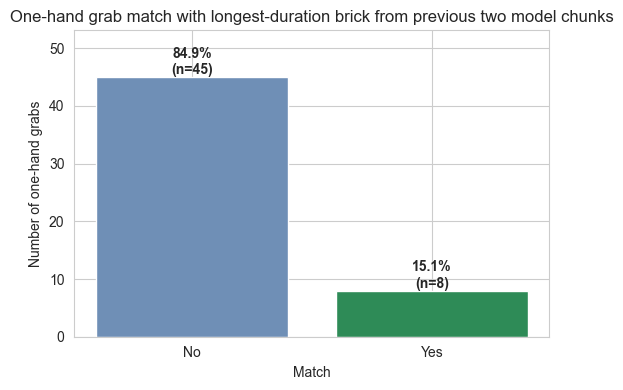

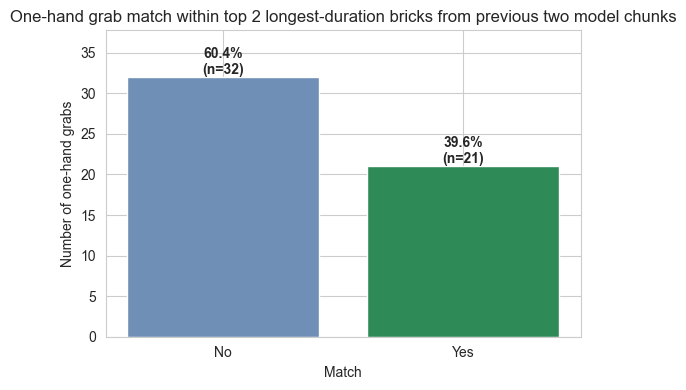

<Axes: title={'center': 'One-hand grab match within top 2 longest-duration bricks from previous two model chunks'}, xlabel='Match', ylabel='Number of one-hand grabs'>

In [82]:
# One-hand match-rate check.
# Includes only grabs where gaze returns to the model before the other hand grabs another brick.
# Looks back over the two most recent continuous model-brick chunks before the grab.
# This cell does not change the earlier pipeline or the previous match-rate plots.

ONE_HAND_RESOURCE_STANCE_PAIRS = {("Resource", "Resource"), ("Resource", "Middle"), ("Middle", "Resource")}
ONE_HAND_TOP_N_TARGETS = 2
PREVIOUS_MODEL_BRICK_CHUNKS = 2
ONE_HAND_TIME_COL = "gaze_capture_time" if "gaze_capture_time" in df.columns else "time_ms"


def one_hand_extract_brick_id(value):
    """Extract brick ID from grouped names like temp_121 or raw names like brick_1x3_pink_res_121."""
    if pd.isna(value):
        return pd.NA

    match = re.search(r"(?:^|_)(?:temp|res|dis)_(\d+)$", str(value), flags=re.IGNORECASE)
    if match:
        return str(int(match.group(1)))
    return pd.NA


def one_hand_first_non_missing(values):
    values = values.dropna()
    return values.iloc[0] if len(values) else pd.NA


def one_hand_most_frequent_first_seen(values):
    values = values.dropna()
    if values.empty:
        return pd.NA

    counts = values.value_counts(sort=False)
    winners = set(counts[counts == counts.max()].index)
    for value in values:
        if value in winners:
            return value
    return pd.NA


def one_hand_ordered_top_by_duration(frame, target_col="fixation_target", duration_col="fixation_duration_ms", top_n=ONE_HAND_TOP_N_TARGETS):
    """Return top targets by summed fixation duration, breaking ties by first appearance."""
    if frame.empty:
        return []

    work = frame[[target_col, duration_col]].dropna(subset=[target_col]).copy()
    if work.empty:
        return []

    work[target_col] = work[target_col].astype(str)
    work[duration_col] = pd.to_numeric(work[duration_col], errors="coerce").fillna(0)

    duration_sums = work.groupby(target_col, sort=False)[duration_col].sum()
    first_seen = {value: i for i, value in enumerate(dict.fromkeys(work[target_col].tolist()))}
    ordered = sorted(duration_sums.index, key=lambda value: (-duration_sums[value], first_seen[value]))
    return ordered[:top_n]


def one_hand_is_resource_stance(left_area, right_area):
    return (str(left_area), str(right_area)) in ONE_HAND_RESOURCE_STANCE_PAIRS


def one_hand_make_fixation_events(df, group_cols=GROUP_COLS, time_col=ONE_HAND_TIME_COL):
    """One row per fixation, including model-area/template-brick status."""
    fixation_rows = df[df["fixation_id"].notna()].copy()
    fixation_rows[time_col] = pd.to_numeric(fixation_rows[time_col], errors="coerce")

    fixation_events = (
        fixation_rows.groupby([*group_cols, "fixation_id"], dropna=False)
        .agg(
            fixation_start_time=(time_col, "min"),
            fixation_end_time=(time_col, "max"),
            fixation_start_ms=("time_ms", "min"),
            fixation_end_ms=("time_ms", "max"),
            fixation_target=("fixation_target", one_hand_first_non_missing),
            fixation_duration_ms=("event_duration_ms", one_hand_first_non_missing),
            fixation_gaze_space=("gaze_space", one_hand_most_frequent_first_seen),
            fixation_target_dominance_ratio=("fixation_target_dominance_ratio", one_hand_first_non_missing),
            fixation_n_unique_targets=("fixation_n_unique_targets", one_hand_first_non_missing),
        )
        .reset_index()
        .sort_values([*group_cols, "fixation_start_time", "fixation_end_time"])
        .reset_index(drop=True)
    )

    fixation_events["fixation_brick_id"] = fixation_events["fixation_target"].apply(one_hand_extract_brick_id)
    fixation_events["is_model_brick_fixation"] = (
        fixation_events["fixation_gaze_space"].eq("model_area")
        & fixation_events["fixation_target"].astype("string").str.startswith("temp_", na=False)
        & fixation_events["fixation_brick_id"].notna()
    )

    return fixation_events


def one_hand_make_resource_brick_grab_events(df, group_cols=GROUP_COLS, time_col=ONE_HAND_TIME_COL):
    """One row per brick grab while both feet indicate the resource side."""
    if not {"LeftFootArea", "RightFootArea"}.issubset(df.columns):
        return pd.DataFrame()

    grab_tables = []
    hand_specs = [
        ("left", "lefthand_grab_id", LEFT_GRABBED_COL),
        ("right", "righthand_grab_id", RIGHT_GRABBED_COL),
    ]

    for hand, grab_id_col, grabbed_col in hand_specs:
        if grab_id_col not in df.columns or grabbed_col not in df.columns:
            continue

        grab_rows = df[df[grab_id_col].notna()].copy()
        if grab_rows.empty:
            continue

        grab_rows[time_col] = pd.to_numeric(grab_rows[time_col], errors="coerce")
        grab_rows["resource_stance_sample"] = [
            one_hand_is_resource_stance(left, right)
            for left, right in zip(
                grab_rows["LeftFootArea"].astype("string"),
                grab_rows["RightFootArea"].astype("string"),
            )
        ]

        grab_events = (
            grab_rows.groupby([*group_cols, grab_id_col], dropna=False)
            .agg(
                grab_start_time=(time_col, "min"),
                grab_end_time=(time_col, "max"),
                grab_start_ms=("time_ms", "min"),
                grab_end_ms=("time_ms", "max"),
                grabbed_object=(grabbed_col, one_hand_most_frequent_first_seen),
                grab_left_foot_area=("LeftFootArea", one_hand_most_frequent_first_seen),
                grab_right_foot_area=("RightFootArea", one_hand_most_frequent_first_seen),
                grab_has_resource_stance=("resource_stance_sample", "any"),
                n_grab_samples=("time_ms", "size"),
            )
            .reset_index()
            .rename(columns={grab_id_col: "grab_id"})
        )

        grab_events["grab_hand"] = hand
        grab_events["grabbed_brick_id"] = grab_events["grabbed_object"].apply(one_hand_extract_brick_id)
        grab_tables.append(grab_events)

    if not grab_tables:
        return pd.DataFrame()

    grab_events = pd.concat(grab_tables, ignore_index=True)
    grab_events = grab_events[
        grab_events["grab_has_resource_stance"]
        & grab_events["grabbed_brick_id"].notna()
    ].copy()

    return grab_events.sort_values([*group_cols, "grab_start_time", "grab_hand"]).reset_index(drop=True)


def one_hand_same_trial_mask(table, row, group_cols=GROUP_COLS):
    mask = pd.Series(True, index=table.index)
    for col in group_cols:
        mask &= table[col].eq(row[col])
    return mask


def one_hand_get_model_return_after_grab(fixation_events, grab, group_cols=GROUP_COLS):
    same_trial = one_hand_same_trial_mask(fixation_events, grab, group_cols=group_cols)
    after_grab = fixation_events["fixation_start_time"].gt(grab["grab_start_time"])
    candidates = fixation_events[same_trial & after_grab & fixation_events["is_model_brick_fixation"]]
    if candidates.empty:
        return None
    return candidates.sort_values("fixation_start_time").iloc[0]


def one_hand_get_next_other_hand_grab(grab_events, grab, group_cols=GROUP_COLS, consumed=None):
    same_trial = one_hand_same_trial_mask(grab_events, grab, group_cols=group_cols)
    after_grab = grab_events["grab_start_time"].gt(grab["grab_start_time"])
    other_hand = grab_events["grab_hand"].ne(grab["grab_hand"])
    candidates = grab_events[same_trial & after_grab & other_hand].copy()
    if consumed:
        candidate_keys = candidates.apply(
            lambda row: tuple(row[col] for col in [*group_cols, "grab_hand", "grab_id"]),
            axis=1,
        )
        candidates = candidates[~candidate_keys.isin(consumed)]
    if candidates.empty:
        return None
    return candidates.sort_values("grab_start_time").iloc[0]


def one_hand_previous_model_frame(fixation_events, grab, group_cols=GROUP_COLS, n_chunks=PREVIOUS_MODEL_BRICK_CHUNKS):
    """Last n continuous model-brick fixation chunks before a grab."""
    same_trial = one_hand_same_trial_mask(fixation_events, grab, group_cols=group_cols)
    before_grab = fixation_events["fixation_end_time"].le(grab["grab_start_time"])
    trial_fixations = fixation_events[same_trial & before_grab].sort_values("fixation_end_time").reset_index(drop=True)

    model_mask = trial_fixations["is_model_brick_fixation"].fillna(False).astype(bool)
    if not model_mask.any():
        return trial_fixations.iloc[0:0].copy()

    chunk_ids = model_mask.ne(model_mask.shift(fill_value=False)).cumsum()
    model_chunk_ids = chunk_ids[model_mask]
    selected_chunk_ids = list(dict.fromkeys(model_chunk_ids.tolist()))[-n_chunks:]

    return trial_fixations[model_mask & chunk_ids.isin(selected_chunk_ids)].copy()


def one_hand_make_grab_matches(df, group_cols=GROUP_COLS):
    """Keep only first grabs followed by model return before any other-hand brick grab."""
    fixation_events = one_hand_make_fixation_events(df, group_cols=group_cols)
    grab_events = one_hand_make_resource_brick_grab_events(df, group_cols=group_cols)
    rows = []
    consumed = set()

    if grab_events.empty:
        return pd.DataFrame()

    for _, grab in grab_events.iterrows():
        grab_key = tuple(grab[col] for col in [*group_cols, "grab_hand", "grab_id"])
        if grab_key in consumed:
            continue

        model_return = one_hand_get_model_return_after_grab(fixation_events, grab, group_cols=group_cols)
        next_other_grab = one_hand_get_next_other_hand_grab(
            grab_events,
            grab,
            group_cols=group_cols,
            consumed=consumed,
        )

        if model_return is None:
            consumed.add(grab_key)
            continue

        if next_other_grab is not None and next_other_grab["grab_start_time"] < model_return["fixation_start_time"]:
            other_key = tuple(next_other_grab[col] for col in [*group_cols, "grab_hand", "grab_id"])
            consumed.update({grab_key, other_key})
            continue

        model_frame = one_hand_previous_model_frame(fixation_events, grab, group_cols=group_cols)
        top_targets = one_hand_ordered_top_by_duration(model_frame, top_n=ONE_HAND_TOP_N_TARGETS)
        top_brick_ids = [one_hand_extract_brick_id(target) for target in top_targets]
        top_brick_ids = [str(brick_id) for brick_id in top_brick_ids if pd.notna(brick_id)]
        grabbed_id = str(grab["grabbed_brick_id"])

        rows.append({
            **{col: grab[col] for col in group_cols},
            "grab_hand": grab["grab_hand"],
            "grab_start_ms": grab["grab_start_ms"],
            "grabbed_object": grab["grabbed_object"],
            "grabbed_brick_id": grabbed_id,
            "model_return_fixation_id": model_return["fixation_id"],
            "model_return_start_ms": model_return["fixation_start_ms"],
            "model_frame_start_ms": model_frame["fixation_start_ms"].min() if len(model_frame) else pd.NA,
            "model_frame_end_ms": model_frame["fixation_end_ms"].max() if len(model_frame) else pd.NA,
            "model_frame_n_fixations": len(model_frame),
            "model_frame_n_chunks": PREVIOUS_MODEL_BRICK_CHUNKS,
            "top_model_frame_targets": top_targets,
            "top_model_frame_brick_ids": top_brick_ids,
            "top_model_frame_ranking": "duration_sum_ms",
            "top1_model_frame_brick_id": top_brick_ids[0] if top_brick_ids else pd.NA,
            "match_top1_model_frame_brick": grabbed_id in top_brick_ids[:1],
            "match_top2_model_frame_bricks": grabbed_id in top_brick_ids[:2],
        })
        consumed.add(grab_key)

    return pd.DataFrame(rows)


def one_hand_plot_yes_no(match_df, match_col, title):
    if match_df.empty:
        print("No one-hand grabs available for plotting.")
        return None

    counts = (
        match_df[match_col]
        .map({False: "No", True: "Yes"})
        .value_counts()
        .reindex(["No", "Yes"], fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(5.5, 4))
    bars = ax.bar(counts.index, counts.values, color=["#6F8FB6", "#2E8B57"])
    ax.set_title(title)
    ax.set_xlabel("Match")
    ax.set_ylabel("Number of one-hand grabs")

    total = counts.sum()
    for bar, count in zip(bars, counts.values):
        pct = 100 * count / total if total else 0
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{pct:.1f}%\n(n={int(count)})",
            ha="center",
            va="bottom",
            fontweight="bold",
        )

    ax.set_ylim(0, max(counts.max() * 1.18, 1))
    plt.tight_layout()
    plt.show()
    return ax


one_hand_grab_match_results = one_hand_make_grab_matches(df)

print(f"One-hand grabs analyzed: {len(one_hand_grab_match_results):,}")
if len(one_hand_grab_match_results):
    display(one_hand_grab_match_results[[
        "grab_hand",
        "grabbed_brick_id",
        "top_model_frame_targets",
        "top_model_frame_brick_ids",
        "top_model_frame_ranking",
        "match_top1_model_frame_brick",
        "match_top2_model_frame_bricks",
    ]].head(10))

one_hand_plot_yes_no(
    one_hand_grab_match_results,
    "match_top1_model_frame_brick",
    "One-hand grab match with longest-duration brick from previous two model chunks",
)

one_hand_plot_yes_no(
    one_hand_grab_match_results,
    "match_top2_model_frame_bricks",
    "One-hand grab match within top 2 longest-duration bricks from previous two model chunks",
)


## 9.5 Dual-Grab Match With Top 4 Previous Model Bricks

This cell only analyzes the dual-grab case. A dual-grab starts with a resource-side brick grab and includes the other hand's next brick grab only when that second grab happens before gaze returns to a model-area template-brick fixation.

For each dual-grab pair, the cell looks backward from the first grab to the most recent continuous model-area brick-fixation frame. It then checks whether both grabbed brick IDs appear in the top 4 longest-duration `fixation_target` brick IDs from that model frame.




Dual-grab pairs analyzed: 19


,first_grab_hand,second_grab_hand,grabbed_brick_ids,top4_model_frame_targets,top4_model_frame_brick_ids,top4_model_frame_ranking,match_both_grabbed_bricks_in_top4
0,right,left,"[29, 27]","[temp_027, temp_029, temp_028, temp_030]","[27, 29, 28, 30]",duration_sum_ms,True
1,right,left,"[64, 60]","[temp_063, temp_062, temp_064]","[63, 62, 64]",duration_sum_ms,False
2,left,right,"[69, 75]","[temp_070, temp_071, temp_074, temp_073]","[70, 71, 74, 73]",duration_sum_ms,False
3,right,left,"[21, 24]","[temp_022, temp_021]","[22, 21]",duration_sum_ms,False
4,left,right,"[22, 21]","[temp_022, temp_021]","[22, 21]",duration_sum_ms,True
5,left,right,"[24, 21]","[temp_022, temp_021]","[22, 21]",duration_sum_ms,False
6,left,right,"[22, 21]","[temp_022, temp_021]","[22, 21]",duration_sum_ms,True
7,left,right,"[24, 21]","[temp_022, temp_021]","[22, 21]",duration_sum_ms,False
8,left,right,"[22, 21]","[temp_022, temp_021]","[22, 21]",duration_sum_ms,True
9,left,right,"[24, 21]","[temp_022, temp_021]","[22, 21]",duration_sum_ms,False


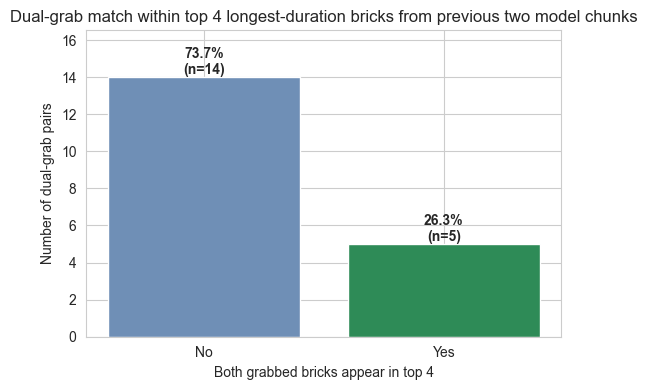

<Axes: title={'center': 'Dual-grab match within top 4 longest-duration bricks from previous two model chunks'}, xlabel='Both grabbed bricks appear in top 4', ylabel='Number of dual-grab pairs'>

In [83]:
# Dual-grab match-rate check.
# Requires the one-hand cell above, because it reuses the same event-building helpers.

DUAL_GRAB_TOP_N_TARGETS = 4


def dual_grab_make_matches(df, group_cols=GROUP_COLS):
    """Keep only dual grabs and check whether both grabbed bricks appear in the top 4 from the previous two model chunks."""
    fixation_events = one_hand_make_fixation_events(df, group_cols=group_cols)
    grab_events = one_hand_make_resource_brick_grab_events(df, group_cols=group_cols)
    rows = []
    consumed = set()

    if grab_events.empty:
        return pd.DataFrame()

    for _, first_grab in grab_events.iterrows():
        first_key = tuple(first_grab[col] for col in [*group_cols, "grab_hand", "grab_id"])
        if first_key in consumed:
            continue

        model_return = one_hand_get_model_return_after_grab(
            fixation_events,
            first_grab,
            group_cols=group_cols,
        )
        second_grab = one_hand_get_next_other_hand_grab(
            grab_events,
            first_grab,
            group_cols=group_cols,
            consumed=consumed,
        )

        if second_grab is None:
            consumed.add(first_key)
            continue
        if model_return is not None and second_grab["grab_start_time"] > model_return["fixation_start_time"]:
            consumed.add(first_key)
            continue

        second_key = tuple(second_grab[col] for col in [*group_cols, "grab_hand", "grab_id"])
        consumed.update({first_key, second_key})

        model_frame = one_hand_previous_model_frame(fixation_events, first_grab, group_cols=group_cols)
        top_targets = one_hand_ordered_top_by_duration(
            model_frame,
            top_n=DUAL_GRAB_TOP_N_TARGETS,
        )
        top_brick_ids = [one_hand_extract_brick_id(target) for target in top_targets]
        top_brick_ids = [str(brick_id) for brick_id in top_brick_ids if pd.notna(brick_id)]

        grabbed_brick_ids = [
            str(first_grab["grabbed_brick_id"]),
            str(second_grab["grabbed_brick_id"]),
        ]

        rows.append({
            **{col: first_grab[col] for col in group_cols},
            "first_grab_hand": first_grab["grab_hand"],
            "second_grab_hand": second_grab["grab_hand"],
            "first_grab_start_ms": first_grab["grab_start_ms"],
            "second_grab_start_ms": second_grab["grab_start_ms"],
            "first_grabbed_object": first_grab["grabbed_object"],
            "second_grabbed_object": second_grab["grabbed_object"],
            "grabbed_brick_ids": grabbed_brick_ids,
            "model_frame_start_ms": model_frame["fixation_start_ms"].min() if len(model_frame) else pd.NA,
            "model_frame_end_ms": model_frame["fixation_end_ms"].max() if len(model_frame) else pd.NA,
            "model_frame_n_fixations": len(model_frame),
            "top4_model_frame_targets": top_targets,
            "top4_model_frame_brick_ids": top_brick_ids,
            "top4_model_frame_ranking": "duration_sum_ms",
            "match_both_grabbed_bricks_in_top4": all(
                brick_id in top_brick_ids for brick_id in grabbed_brick_ids
            ),
        })

    return pd.DataFrame(rows)


def dual_grab_plot_yes_no(match_df, match_col, title):
    if match_df.empty:
        print("No dual-grab pairs available for plotting.")
        return None

    counts = (
        match_df[match_col]
        .map({False: "No", True: "Yes"})
        .value_counts()
        .reindex(["No", "Yes"], fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(5.5, 4))
    bars = ax.bar(counts.index, counts.values, color=["#6F8FB6", "#2E8B57"])
    ax.set_title(title)
    ax.set_xlabel("Both grabbed bricks appear in top 4")
    ax.set_ylabel("Number of dual-grab pairs")

    total = counts.sum()
    for bar, count in zip(bars, counts.values):
        pct = 100 * count / total if total else 0
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{pct:.1f}%\n(n={int(count)})",
            ha="center",
            va="bottom",
            fontweight="bold",
        )

    ax.set_ylim(0, max(counts.max() * 1.18, 1))
    plt.tight_layout()
    plt.show()
    return ax


dual_grab_match_results = dual_grab_make_matches(df)

print(f"Dual-grab pairs analyzed: {len(dual_grab_match_results):,}")
if len(dual_grab_match_results):
    display(dual_grab_match_results[[
        "first_grab_hand",
        "second_grab_hand",
        "grabbed_brick_ids",
        "top4_model_frame_targets",
        "top4_model_frame_brick_ids",
        "top4_model_frame_ranking",
        "match_both_grabbed_bricks_in_top4",
    ]].head(10))

dual_grab_plot_yes_no(
    dual_grab_match_results,
    "match_both_grabbed_bricks_in_top4",
    "Dual-grab match within top 4 longest-duration bricks from previous two model chunks",
)


## 9.6 Combined One-Hand and Dual-Grab Match Rate

This cell combines both accepted conditions into one Yes/No plot. One-hand grabs are matched when the grabbed brick appears in the top 2 longest-duration previous model-frame template bricks. Dual-grab pairs are matched when both grabbed bricks appear in the top 5 longest-duration previous model-frame template bricks.




Combined grab decisions analyzed: 72


,condition_type,match_combined_rule,n
0,dual_grab,False,14
1,dual_grab,True,5
2,one_hand,False,32
3,one_hand,True,21


,condition_type,grabbed_brick_ids,top_n_checked,top_model_frame_brick_ids,match_combined_rule
0,one_hand,[62],2,"[63, 64]",False
1,one_hand,[23],2,"[22, 21]",False
2,one_hand,[21],2,"[22, 21]",True
3,one_hand,[23],2,"[22, 21]",False
4,one_hand,[21],2,"[22, 21]",True
5,one_hand,[23],2,"[22, 21]",False
6,one_hand,[21],2,"[22, 21]",True
7,one_hand,[23],2,"[22, 21]",False
8,one_hand,[21],2,"[22, 21]",True
9,one_hand,[23],2,"[22, 21]",False


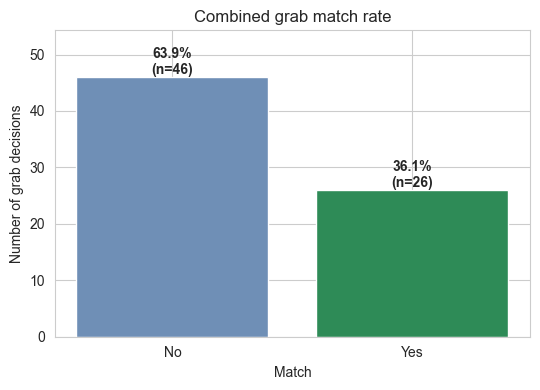

<Axes: title={'center': 'Combined grab match rate'}, xlabel='Match', ylabel='Number of grab decisions'>

In [84]:
# Combined match-rate plot.
# One-hand: grabbed brick appears in top 2 duration-ranked temp_ bricks from the previous two model chunks.
# Dual-grab: both grabbed bricks appear in top 4 duration-ranked temp_ bricks from the previous two model chunks.

COMBINED_DUAL_TOP_N_TARGETS = 4


def combined_dual_grab_make_matches(df, group_cols=GROUP_COLS):
    """Dual-grab pairs matched against top 4 duration-ranked temp_ bricks from the previous two model chunks."""
    fixation_events = one_hand_make_fixation_events(df, group_cols=group_cols)
    grab_events = one_hand_make_resource_brick_grab_events(df, group_cols=group_cols)
    rows = []
    consumed = set()

    if grab_events.empty:
        return pd.DataFrame()

    for _, first_grab in grab_events.iterrows():
        first_key = tuple(first_grab[col] for col in [*group_cols, "grab_hand", "grab_id"])
        if first_key in consumed:
            continue

        model_return = one_hand_get_model_return_after_grab(
            fixation_events,
            first_grab,
            group_cols=group_cols,
        )
        second_grab = one_hand_get_next_other_hand_grab(
            grab_events,
            first_grab,
            group_cols=group_cols,
            consumed=consumed,
        )

        if second_grab is None:
            consumed.add(first_key)
            continue
        if model_return is not None and second_grab["grab_start_time"] > model_return["fixation_start_time"]:
            consumed.add(first_key)
            continue

        second_key = tuple(second_grab[col] for col in [*group_cols, "grab_hand", "grab_id"])
        consumed.update({first_key, second_key})

        model_frame = one_hand_previous_model_frame(fixation_events, first_grab, group_cols=group_cols)
        top_targets = one_hand_ordered_top_by_duration(
            model_frame,
            top_n=COMBINED_DUAL_TOP_N_TARGETS,
        )
        top_brick_ids = [one_hand_extract_brick_id(target) for target in top_targets]
        top_brick_ids = [str(brick_id) for brick_id in top_brick_ids if pd.notna(brick_id)]

        grabbed_brick_ids = [
            str(first_grab["grabbed_brick_id"]),
            str(second_grab["grabbed_brick_id"]),
        ]

        rows.append({
            **{col: first_grab[col] for col in group_cols},
            "condition_type": "dual_grab",
            "first_grab_hand": first_grab["grab_hand"],
            "second_grab_hand": second_grab["grab_hand"],
            "first_grab_start_ms": first_grab["grab_start_ms"],
            "second_grab_start_ms": second_grab["grab_start_ms"],
            "grabbed_brick_ids": grabbed_brick_ids,
            "top_model_frame_targets": top_targets,
            "top_model_frame_brick_ids": top_brick_ids,
            "top_n_checked": COMBINED_DUAL_TOP_N_TARGETS,
            "match_combined_rule": all(brick_id in top_brick_ids for brick_id in grabbed_brick_ids),
        })

    return pd.DataFrame(rows)


def combined_make_match_results(df):
    """Combine one-hand top-2 matches and dual-grab top-5 matches into one table."""
    combined_tables = []

    one_hand = one_hand_make_grab_matches(df).copy()
    if not one_hand.empty:
        one_hand_combined = pd.DataFrame({
            "condition_type": "one_hand",
            "participant_id": one_hand["participant_id"],
            "condition_number": one_hand["condition_number"],
            "trial_number": one_hand["trial_number"],
            "first_grab_hand": one_hand["grab_hand"],
            "second_grab_hand": pd.NA,
            "grabbed_brick_ids": one_hand["grabbed_brick_id"].map(lambda x: [str(x)]),
            "top_model_frame_targets": one_hand["top_model_frame_targets"],
            "top_model_frame_brick_ids": one_hand["top_model_frame_brick_ids"],
            "top_n_checked": 2,
            "match_combined_rule": one_hand["match_top2_model_frame_bricks"].astype(bool),
        })
        combined_tables.append(one_hand_combined)

    dual = combined_dual_grab_make_matches(df).copy()
    if not dual.empty:
        combined_tables.append(dual)

    if not combined_tables:
        return pd.DataFrame()

    return pd.concat(combined_tables, ignore_index=True)


def combined_plot_yes_no(match_df, match_col="match_combined_rule"):
    if match_df.empty:
        print("No combined grab decisions available for plotting.")
        return None

    counts = (
        match_df[match_col]
        .map({False: "No", True: "Yes"})
        .value_counts()
        .reindex(["No", "Yes"], fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(5.5, 4))
    bars = ax.bar(counts.index, counts.values, color=["#6F8FB6", "#2E8B57"])
    ax.set_title("Combined grab match rate")
    ax.set_xlabel("Match")
    ax.set_ylabel("Number of grab decisions")

    total = counts.sum()
    for bar, count in zip(bars, counts.values):
        pct = 100 * count / total if total else 0
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{pct:.1f}%\n(n={int(count)})",
            ha="center",
            va="bottom",
            fontweight="bold",
        )

    ax.set_ylim(0, max(counts.max() * 1.18, 1))
    plt.tight_layout()
    plt.show()
    return ax


combined_grab_match_results = combined_make_match_results(df)

print(f"Combined grab decisions analyzed: {len(combined_grab_match_results):,}")
if len(combined_grab_match_results):
    display(
        combined_grab_match_results
        .groupby(["condition_type", "match_combined_rule"])
        .size()
        .rename("n")
        .reset_index()
    )
    display(combined_grab_match_results[[
        "condition_type",
        "grabbed_brick_ids",
        "top_n_checked",
        "top_model_frame_brick_ids",
        "match_combined_rule",
    ]].head(10))

combined_plot_yes_no(combined_grab_match_results)


In [13]:
def get_time_window(df, cond, trial, t_start_ms, t_end_ms):
    return df[
        (df["condition_number"] == cond)
        & (df["trial_number"] == trial)
        & (df["time_ms"] >= t_start_ms)
        & (df["time_ms"] <= t_end_ms)
    ].copy()


def make_saccade_events(df):
    return (
        df.dropna(subset=["saccade_id"])
        .groupby(GROUP_COLS + ["saccade_id"], as_index=False, dropna=False)
        .agg(
            duration_ms=("event_duration_ms", "first"),
            start_time_ms=("time_ms", "min"),
            end_time_ms=("time_ms", "max"),
            peak_velocity=("angular_velocity", "max"),
        )
    )


def make_basic_counts(df):
    left_brick_grabs = df[
        df[LEFT_GRABBED_COL].astype("string").str.contains("brick", case=False, na=False)
    ]["lefthand_grab_id"].nunique()
    right_brick_grabs = df[
        df[RIGHT_GRABBED_COL].astype("string").str.contains("brick", case=False, na=False)
    ]["righthand_grab_id"].nunique()

    return pd.Series({
        "fixations": df["fixation_id"].nunique(),
        "saccades": df["saccade_id"].nunique(),
        "left_grabs": df["lefthand_grab_id"].nunique(),
        "right_grabs": df["righthand_grab_id"].nunique(),
        "left_brick_grabs": left_brick_grabs,
        "right_brick_grabs": right_brick_grabs,
    })


basic_counts = make_basic_counts(df)
saccade_events = make_saccade_events(df)

print("Basic counts")
print(basic_counts.to_string())
print("\nSaccade duration summary")
print(saccade_events["duration_ms"].describe().to_string())


Basic counts
fixations            9662
saccades             9646
left_grabs             53
right_grabs            56
left_brick_grabs       37
right_brick_grabs      54

Saccade duration summary
count    9646.000000
mean       52.644600
std        78.651504
min         5.000600
25%         5.000700
50%        25.003500
75%        65.007800
max      1085.130200


In [19]:
df['LeftFootArea'].value_counts()

LeftFootArea
Work        240198
Resource     71036
Model        28718
Middle        2861
Name: count, dtype: int64

In [12]:
df.head()

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,hit_obj_group,gaze_space,saccade_id,fixation_id,event_duration_ms,fixation_target,lefthand_grab_id,righthand_grab_id,fixation_target_dominance_ratio,fixation_n_unique_targets
0,1000002521039813400,1778070611245,899.6576,0.793753,363803,0.775723,Valid,0.005104,-0.021595,0.999754,...,walls,room,<NA>,1,340.047872,walls,<NA>,<NA>,1.0,1
1,1000002521044813400,1778070611245,899.6576,0.790839,363804,0.773573,Valid,0.005013,-0.021721,0.999752,...,walls,room,<NA>,1,340.047872,walls,<NA>,<NA>,1.0,1
2,1000002521049813100,1778070611245,899.6576,0.787299,363805,0.732540,Valid,0.004990,-0.022086,0.999744,...,walls,room,<NA>,1,340.047872,walls,<NA>,<NA>,1.0,1
3,1000002521054813200,1778070611245,899.6576,0.784656,363806,0.721859,Valid,0.005019,-0.022624,0.999731,...,walls,room,<NA>,1,340.047872,walls,<NA>,<NA>,1.0,1
4,1000002521059812900,1778070611245,899.6576,0.782246,363807,0.746475,Valid,0.005032,-0.023158,0.999719,...,walls,room,<NA>,1,340.047872,walls,<NA>,<NA>,1.0,1


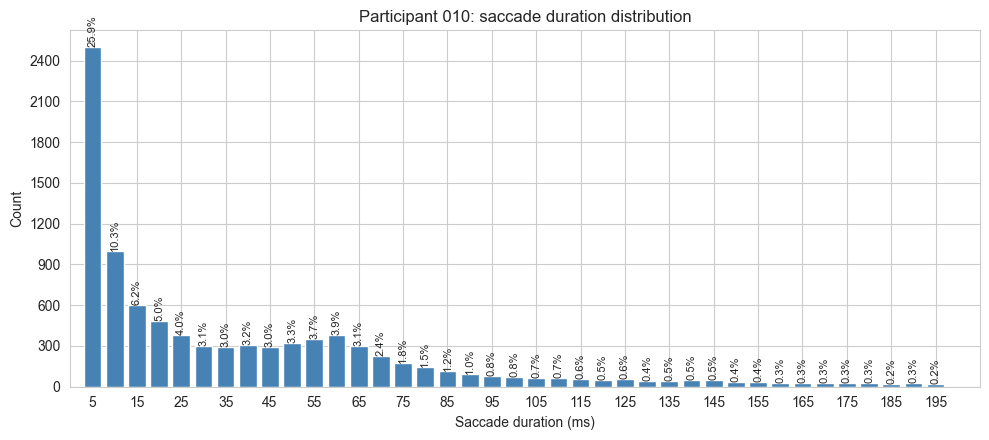

In [20]:
def plot_saccade_duration_histogram(saccade_events, min_ms=5, max_ms=200, bin_ms=5):
    plot_data = saccade_events[
        (saccade_events["duration_ms"] >= min_ms)
        & (saccade_events["duration_ms"] <= max_ms)
    ].copy()
    if plot_data.empty:
        print("No saccades in requested duration range.")
        return None

    plot_data["duration_bin"] = (bin_ms * (plot_data["duration_ms"] / bin_ms).round()).astype(int)
    duration_counts = plot_data["duration_bin"].value_counts().sort_index()
    total = len(saccade_events)

    fig, ax = plt.subplots(figsize=(10, 4.5))
    bars = ax.bar(duration_counts.index, duration_counts.values, width=bin_ms * 0.8, color="steelblue")

    for bar, count in zip(bars, duration_counts.values):
        pct = 100 * count / total if total else 0
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            count,
            f"{pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90,
        )

    ax.set_xlabel("Saccade duration (ms)")
    ax.set_ylabel("Count")
    ax.set_title(f"Participant {PARTICIPANT_ID}: saccade duration distribution")
    ax.set_xticks(np.arange(min_ms, max_ms + bin_ms, bin_ms * 2))
    ax.set_xlim(min_ms - bin_ms, max_ms + bin_ms)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    return ax


plot_saccade_duration_histogram(saccade_events)
plt.show()


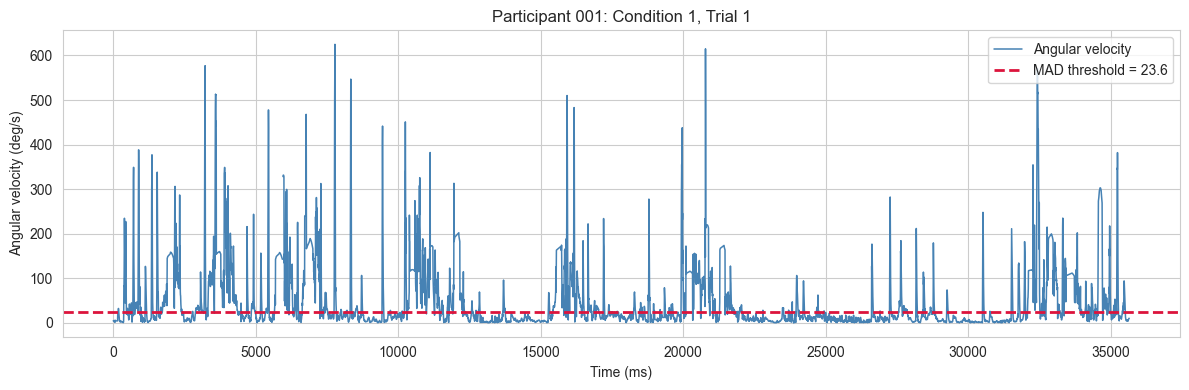

In [21]:
def plot_angular_velocity_trace(df, cond=1, trial=1, t_start_ms=None, t_end_ms=None):
    sub = df[
        (df["condition_number"] == cond)
        & (df["trial_number"] == trial)
    ].copy()
    if t_start_ms is not None:
        sub = sub[sub["time_ms"] >= t_start_ms]
    if t_end_ms is not None:
        sub = sub[sub["time_ms"] <= t_end_ms]

    sub["time_ms"] = pd.to_numeric(sub["time_ms"], errors="coerce")
    sub["angular_velocity"] = pd.to_numeric(sub["angular_velocity"], errors="coerce")
    threshold = pd.to_numeric(sub["mad_threshold"], errors="coerce").dropna()
    threshold = threshold.iloc[0] if not threshold.empty else np.nan

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(sub["time_ms"], sub["angular_velocity"], lw=1.1, color="steelblue", label="Angular velocity")
    if np.isfinite(threshold):
        ax.axhline(threshold, color="crimson", ls="--", lw=2, label=f"MAD threshold = {threshold:.1f}")
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Angular velocity (deg/s)")
    ax.set_title(f"Participant {PARTICIPANT_ID}: Condition {cond}, Trial {trial}")
    ax.legend(loc="upper right")
    plt.tight_layout()
    return ax


plot_angular_velocity_trace(df, cond=1, trial=1)
plt.show()


# 10. Final Objects

Main objects produced by this notebook:
- `df`: cleaned, annotated sample-level merged data for one participant, including `hit_obj_group`, `gaze_space`, and `fixation_target`
- `qc_summary`: condition/trial QC summary
- `saccade_events`: one row per saccade event
- `grab_fixation_matches`: one row per valid brick grab matched to previous template/model-brick fixation
- `melnik_transition_events`: event-level M/W/R fixation-to-fixation transitions for checking transition detection
- `melnik_transition_trial_counts`: trial-level counts for Melnik-style M/W/R transitions
- `melnik_transition_summary`: mean +/- SEM transition counts by delay condition and transition type
- `melnik_fig5_model_return_counts`: trial-level WM/RM model-area return counts
- `melnik_fig5_total_transition_counts`: trial-level total M/W/R transition counts
- `melnik_fig5_trial_durations`: trial-level duration in seconds from `time_ms`
